# Segmentação de Clientes Olist — RFM, Segmentação Estratégica e Clusterização

## Objetivo do projeto
Este projeto tem como objetivo segmentar clientes de um e-commerce com base em comportamento de compra, valor gerado e risco de inatividade. A proposta vai além do RFM clássico, incorporando variáveis de experiência e uma etapa de clusterização para gerar grupos mais acionáveis para CRM, retenção, reativação e visualização em dashboard.

> O RFM exige dados transacionais, como cliente, pedido, data e valor. Neste projeto, utilizamos o dataset público da Olist para construir essa segmentação a partir de compras reais.

---

## Perguntas de negócio
- Quais clientes concentram maior valor?
- Quais clientes estão em risco de churn?
- Quais perfis têm maior potencial de retenção ou reativação?
- Como transformar essa segmentação em uma base pronta para Power BI e tomada de decisão?

---

## Estrutura
1. Carregamento dos dados
2. Preparação e regras de negócio
3. Construção do RFM (Recency, Frequency, Monetary)
4. EDA da base analítica RFM
5. Preparação para clusterização
6. Escolha do número de clusters (K)
7. Clusterização final (K-Means)
8. Naming dos clusters (tradução para negócio)
9. Validação estatística dos insights
10. Enriquecimento com reviews e pagamentos
11. Exportação para Power BI (star schema)

---

## Por que isso importa
Uma segmentação comportamental bem construída permite decisões mais eficientes, como:
- **Reativação** de clientes em risco
- **Retenção** de clientes valiosos
- **Upsell** e priorização de clientes de maior potencial
- **Onboarding e aceleração da segunda compra** para clientes recentes

In [ ]:
# BOOTSTRAP - cria src/ e config/ no kernel atual
import os
from pathlib import Path

os.makedirs("src", exist_ok=True)
os.makedirs("config", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("data/powerbi", exist_ok=True)

PROJECT_FILES = {
    "src/__init__.py": '# src/__init__.py\nimport logging\n\nlogging.basicConfig(\n level=logging.INFO,\n format="%(asctime)s | %(name)s | %(levelname)s | %(message)s",\n datefmt="%Y-%m-%d %H:%M:%S",\n)\n',
    "src/config.py": '# src/config.py\n"""Carrega e expõe o config.yaml centralizado do projeto."""\n\n# Standard library\nfrom pathlib import Path\n\n# Third-party\nimport yaml\n\n\ndef load_config(path: str = "config/config.yaml") -> dict:\n """Carrega o arquivo de configuração YAML.\n\n Args:\n path: Caminho para o config.yaml (relativo à raiz do projeto).\n\n Returns:\n Dicionário com os parâmetros do projeto.\n\n Raises:\n FileNotFoundError: Se o arquivo não existir.\n """\n config_path = Path(path)\n if not config_path.exists():\n raise FileNotFoundError(f"Arquivo de configuração não encontrado: {config_path.resolve()}")\n\n with open(config_path, "r", encoding="utf-8") as f:\n return yaml.safe_load(f)\n\n\nCONFIG = load_config()\n',
    "src/utils.py": '# src/utils.py\n"""Funções utilitárias reutilizáveis do projeto RFM Olist."""\n\n# Standard library\nimport logging\n\n# Third-party\nimport numpy as np\nimport pandas as pd\n\nlogger = logging.getLogger(__name__)\n\n\ndef gini_coefficient(values: pd.Series) -> float:\n """Calcula o Coeficiente de Gini para uma distribuição.\n\n Args:\n values: Série de valores não-negativos (ex: Monetary).\n\n Returns:\n Gini entre 0 (igualdade perfeita) e 1 (desigualdade extrema).\n """\n arr = np.sort(values.dropna().values)\n if len(arr) == 0 or arr.sum() == 0:\n return 0.0\n n = len(arr)\n idx = np.arange(1, n + 1)\n return float((2 * (idx * arr).sum()) / (n * arr.sum()) - (n + 1) / n)\n\n\ndef lorenz_curve(values: pd.Series) -> pd.DataFrame:\n """Calcula os pontos da Curva de Lorenz.\n\n Args:\n values: Série de valores monetários.\n\n Returns:\n DataFrame com colunas \'cumulative_customers_pct\' e \'cumulative_monetary_pct\'.\n """\n sorted_vals = values.sort_values().reset_index(drop=True)\n n = len(sorted_vals)\n df = pd.DataFrame({\n "cumulative_customers_pct": ((sorted_vals.index + 1) / n) * 100,\n "cumulative_monetary_pct": (sorted_vals.cumsum() / sorted_vals.sum()) * 100,\n })\n return df\n\n\ndef describe_skew(s: pd.Series) -> pd.Series:\n """Retorna estatísticas descritivas incluindo assimetria.\n\n Args:\n s: Série numérica.\n\n Returns:\n Série com count, mean, median, std, min, p25, p75, p95, max, skew.\n """\n return pd.Series({\n "count": s.count(),\n "mean": s.mean(),\n "median": s.median(),\n "std": s.std(),\n "min": s.min(),\n "p25": s.quantile(0.25),\n "p75": s.quantile(0.75),\n "p95": s.quantile(0.95),\n "max": s.max(),\n "skew": s.skew(),\n })\n',
    "src/data_quality.py": '# src/data_quality.py\n"""Validações e quality checks para as tabelas Olist."""\n\n# Standard library\nimport logging\n\n# Third-party\nimport pandas as pd\n\nlogger = logging.getLogger(__name__)\n\n\ndef check_orders(orders: pd.DataFrame) -> None:\n """Valida a tabela de pedidos.\n\n Args:\n orders: DataFrame de pedidos.\n\n Raises:\n AssertionError: Se houver duplicatas em order_id ou datas faltantes.\n """\n assert orders["order_id"].is_unique, "Duplicatas em order_id!"\n assert orders["order_purchase_timestamp"].notna().all(), "Datas faltantes em order_purchase_timestamp!"\n logger.info(\n f"orders OK: {len(orders):,} linhas, "\n f"{orders[\'customer_id\'].nunique():,} clientes únicos"\n )\n\n\ndef check_customers(customers: pd.DataFrame) -> None:\n """Valida a tabela de clientes.\n\n Args:\n customers: DataFrame de clientes.\n """\n assert customers["customer_id"].is_unique, "customer_id duplicado!"\n n_null = customers["customer_unique_id"].isna().sum()\n if n_null > 0:\n logger.warning(f"{n_null} customer_unique_id nulos detectados — serão removidos no merge")\n logger.info(\n f"customers OK: {len(customers):,} linhas, "\n f"{customers[\'customer_unique_id\'].nunique():,} clientes únicos"\n )\n\n\ndef deduplicate_reviews(reviews: pd.DataFrame) -> pd.DataFrame:\n """Remove duplicatas de reviews — mantém a mais recente por order_id.\n\n O dataset Olist tem múltiplos registros por order_id na tabela de reviews.\n Esse comportamento é conhecido e deve ser tratado antes do merge.\n\n Args:\n reviews: DataFrame de reviews bruto.\n\n Returns:\n DataFrame deduplicado com uma review por order_id.\n """\n before = len(reviews)\n reviews = (\n reviews.sort_values("review_creation_date")\n .drop_duplicates("order_id", keep="last")\n .reset_index(drop=True)\n )\n logger.info(f"Reviews deduplicadas: {before:,} → {len(reviews):,}")\n return reviews\n\n\ndef validate_snapshot(orders_base: pd.DataFrame, snapshot_date: pd.Timestamp) -> None:\n """Garante que não há pedidos posteriores à snapshot_date.\n\n Args:\n orders_base: DataFrame de pedidos filtrados.\n snapshot_date: Data de referência do RFM.\n\n Raises:\n AssertionError: Se houver pedidos após a snapshot.\n """\n max_date = orders_base["order_purchase_timestamp"].max()\n assert max_date <= snapshot_date, (\n f"Pedidos posteriores à snapshot_date detectados! "\n f"max={max_date}, snapshot={snapshot_date}"\n )\n logger.info(f"Snapshot OK: max_date={max_date.date()}, snapshot={snapshot_date.date()}")\n\n\ndef quality_report(df: pd.DataFrame, name: str) -> dict:\n """Gera relatório de qualidade de um DataFrame.\n\n Args:\n df: DataFrame a inspecionar.\n name: Nome da tabela (para identificação no relatório).\n\n Returns:\n Dicionário com linhas, nulos por coluna e tipos.\n """\n report = {\n "tabela": name,\n "linhas": len(df),\n "nulls_por_coluna": df.isna().sum().to_dict(),\n "tipos": df.dtypes.astype(str).to_dict(),\n }\n null_cols = {c: v for c, v in report["nulls_por_coluna"].items() if v > 0}\n if null_cols:\n logger.warning(f"[{name}] Colunas com nulos: {null_cols}")\n else:\n logger.info(f"[{name}] Sem nulos detectados ({report[\'linhas\']:,} linhas)")\n return report\n',
    "src/data_loader.py": '# src/data_loader.py\n"""Carregamento dos datasets Olist com auto-detecção robusta de caminhos.\n\nFunciona em qualquer ambiente:\n- Local Windows/Linux/Mac (data/raw/, ./, etc.)\n- Google Colab (/content/, /content/data/, subpastas)\n- Kaggle (/kaggle/input/brazilian-ecommerce/, /kaggle/working/)\n- Notebook em qualquer pasta (busca recursiva)\n"""\n\n# Standard library\nimport logging\nfrom pathlib import Path\n\n# Third-party\nimport pandas as pd\n\nlogger = logging.getLogger(__name__)\n\nREQUIRED_FILES = {\n "orders": "olist_orders_dataset.csv",\n "customers": "olist_customers_dataset.csv",\n "order_items": "olist_order_items_dataset.csv",\n "payments": "olist_order_payments_dataset.csv",\n "reviews": "olist_order_reviews_dataset.csv",\n}\n\n\ndef _has_all_csvs(directory: Path) -> bool:\n """Verifica se um diretório contém TODOS os 5 CSVs Olist necessários."""\n if not directory.exists() or not directory.is_dir():\n return False\n return all((directory / f).exists() for f in REQUIRED_FILES.values())\n\n\ndef find_data_directory(start_hint: str = "data/raw") -> Path:\n """Encontra automaticamente o diretório com os CSVs Olist.\n\n Estratégia (em ordem):\n 1. start_hint (ex: \'data/raw\')\n 2. Diretório atual (.)\n 3. Caminhos comuns de Colab/Kaggle\n 4. Busca recursiva a partir da cwd (até 4 níveis)\n\n Args:\n start_hint: Primeiro caminho a tentar.\n\n Returns:\n Path do diretório que contém os 5 CSVs.\n\n Raises:\n FileNotFoundError: Se não achar em nenhum lugar plausível.\n """\n candidates = [\n Path(start_hint),\n Path("."),\n Path("data/raw"),\n Path("data"),\n Path("/content"),\n Path("/content/data"),\n Path("/content/data/raw"),\n Path("/content/sample_data"),\n Path("/kaggle/input/brazilian-ecommerce"),\n Path("/kaggle/input/olist-brazilian-ecommerce"),\n Path("/kaggle/working"),\n ]\n\n # 1) Testa candidatos diretos\n for c in candidates:\n if _has_all_csvs(c):\n logger.info(f"CSVs Olist localizados em: {c.resolve()}")\n return c.resolve()\n\n # 2) Busca recursiva a partir da cwd (limitada a 4 niveis para nao explodir)\n cwd = Path(".").resolve()\n logger.info(f"Buscando recursivamente a partir de {cwd}...")\n for orders_csv in cwd.rglob("olist_orders_dataset.csv"):\n parent = orders_csv.parent\n if _has_all_csvs(parent):\n logger.info(f"CSVs Olist localizados em (busca recursiva): {parent}")\n return parent\n\n # 3) Tambem tenta a partir de /content e /kaggle/input se existirem\n for root in [Path("/content"), Path("/kaggle/input")]:\n if root.exists():\n for orders_csv in root.rglob("olist_orders_dataset.csv"):\n parent = orders_csv.parent\n if _has_all_csvs(parent):\n logger.info(f"CSVs Olist localizados em: {parent}")\n return parent\n\n # 4) Falhou — mensagem util\n tried = "\\n".join(f" - {c}" for c in candidates)\n raise FileNotFoundError(\n "Não consegui encontrar os 5 CSVs Olist em nenhum lugar conhecido.\\n"\n f"Locais testados:\\n{tried}\\n\\n"\n "Soluções:\\n"\n " 1. Faça upload dos CSVs para a pasta atual ou data/raw/\\n"\n " 2. Ou passe o caminho explicitamente: load_all_data(\'/seu/caminho\')\\n"\n "\\nArquivos esperados:\\n"\n + "\\n".join(f" - {f}" for f in REQUIRED_FILES.values())\n )\n\n\ndef load_all_data(raw_dir: str = None) -> dict:\n """Carrega todos os datasets Olist necessários para o pipeline RFM.\n\n Args:\n raw_dir: Diretório contendo os CSVs. Se None, auto-detecta.\n\n Returns:\n Dicionário com DataFrames: orders, customers, order_items, payments, reviews.\n\n Raises:\n FileNotFoundError: Se não conseguir localizar os CSVs.\n """\n if raw_dir is None:\n raw_path = find_data_directory()\n else:\n raw_path = Path(raw_dir)\n if not _has_all_csvs(raw_path):\n # Auto-fallback se o caminho passado nao tem os CSVs\n logger.warning(\n f"CSVs incompletos em \'{raw_path}\'. Iniciando auto-detecção..."\n )\n raw_path = find_data_directory(start_hint=str(raw_path))\n\n parse_dates = {"orders": ["order_purchase_timestamp", "order_delivered_customer_date"]}\n\n data = {}\n for key, filename in REQUIRED_FILES.items():\n path = raw_path / filename\n kwargs = {}\n if key in parse_dates:\n kwargs["parse_dates"] = parse_dates[key]\n data[key] = pd.read_csv(path, **kwargs)\n logger.info(f"{key}: {data[key].shape[0]:,} linhas × {data[key].shape[1]} colunas")\n\n return data\n\n\ndef load_from_project_root(raw_dir: str = "data/raw") -> dict:\n """Wrapper amigável: auto-detecta os CSVs em qualquer ambiente.\n\n Funciona em local, Colab, Kaggle e qualquer pasta com busca recursiva.\n\n Args:\n raw_dir: Caminho preferencial (apenas como hint — se não tiver os CSVs,\n a função busca em outros lugares automaticamente).\n\n Returns:\n Dicionário com os 5 DataFrames Olist.\n """\n return load_all_data(raw_dir)\n',
    "src/rfm.py": '# src/rfm.py\n"""Construção da tabela RFM a partir das tabelas Olist."""\n\n# Standard library\nimport logging\n\n# Third-party\nimport pandas as pd\n\nlogger = logging.getLogger(__name__)\n\n\ndef build_orders_base(data: dict, status_filter: str = "delivered") -> pd.DataFrame:\n """Constrói a base order-centric com filtro de status e merges necessários.\n\n Args:\n data: Dicionário com DataFrames (orders, customers, order_items, payments, reviews).\n status_filter: Status de pedido a filtrar (padrão: \'delivered\').\n\n Returns:\n DataFrame com uma linha por pedido enriquecido com pagamentos, itens e reviews.\n """\n orders = data["orders"]\n customers = data["customers"]\n order_items = data["order_items"]\n payments = data["payments"]\n reviews = data["reviews"]\n\n # Filtra apenas pedidos entregues\n orders_delivered = orders[orders["order_status"] == status_filter].copy()\n logger.info(\n f"Pedidos com status=\'{status_filter}\': "\n f"{len(orders_delivered):,} de {len(orders):,} total"\n )\n\n # Agrega valor por pedido (itens)\n items_value = order_items.groupby("order_id", as_index=False).agg(\n total_items_value=("price", "sum"),\n n_items=("order_item_id", "count"),\n )\n\n # Agrega valor por pedido (pagamentos)\n pay_value = payments.groupby("order_id", as_index=False).agg(\n total_payment=("payment_value", "sum"),\n n_payments=("payment_sequential", "max"),\n )\n\n # Agrega review (média por pedido — já deduplicada antes)\n rev_value = reviews.groupby("order_id", as_index=False).agg(\n review_score=("review_score", "mean"),\n )\n\n # Monta base order-centric\n orders_base = (\n orders_delivered[["order_id", "customer_id", "order_purchase_timestamp"]]\n .merge(items_value, on="order_id", how="left")\n .merge(pay_value, on="order_id", how="left")\n .merge(rev_value, on="order_id", how="left")\n )\n\n # Adiciona customer_unique_id e estado\n orders_base = orders_base.merge(\n customers[["customer_id", "customer_unique_id", "customer_state"]],\n on="customer_id",\n how="left",\n )\n\n # Monetary: prioriza total_payment; fallback para total_items_value\n orders_base["monetary_value"] = orders_base["total_payment"].fillna(\n orders_base["total_items_value"]\n )\n\n logger.info(f"orders_base construída: {len(orders_base):,} linhas")\n return orders_base\n\n\ndef build_rfm(data: dict, snapshot_date: str, status_filter: str = "delivered") -> pd.DataFrame:\n """Constrói a tabela RFM a partir das tabelas Olist.\n\n Args:\n data: Dicionário com as tabelas brutas (orders, customers, etc.).\n snapshot_date: Data de referência para cálculo da Recency (formato YYYY-MM-DD).\n Deve ser fixada e versionada — não usar max() dinâmico.\n status_filter: Status de pedido a filtrar.\n\n Returns:\n DataFrame com uma linha por customer_unique_id contendo:\n - Recency (int): Dias desde a última compra até a snapshot_date.\n - Frequency (int): Número de pedidos únicos entregues.\n - Monetary (float): Soma do valor pago.\n - Avg_Order_Value (float): Ticket médio por pedido.\n - Items (int): Total de itens comprados.\n - Avg_Review (float): Nota média de reviews (pode ter NaN).\n\n Raises:\n ValueError: Se snapshot_date for anterior à última compra dos dados.\n """\n snap = pd.Timestamp(snapshot_date)\n orders_base = build_orders_base(data, status_filter)\n\n # Valida snapshot\n max_date = orders_base["order_purchase_timestamp"].max()\n if max_date > snap:\n raise ValueError(\n f"snapshot_date \'{snapshot_date}\' é anterior à data máxima dos dados ({max_date.date()}). "\n "Ajuste o config.yaml ou filtre os dados."\n )\n\n rfm = (\n orders_base.groupby("customer_unique_id", as_index=False)\n .agg(\n Recency=("order_purchase_timestamp", lambda x: (snap - x.max()).days),\n Frequency=("order_id", "nunique"),\n Monetary=("monetary_value", "sum"),\n Avg_Order_Value=("monetary_value", "mean"),\n Items=("n_items", "sum"),\n Avg_Review=("review_score", "mean"),\n )\n )\n\n logger.info(\n f"RFM construída: {len(rfm):,} clientes únicos | "\n f"Recency médio={rfm[\'Recency\'].mean():.1f} dias | "\n f"Monetary médio=R${rfm[\'Monetary\'].mean():.2f}"\n )\n return rfm\n',
    "src/segmentation.py": '# src/segmentation.py\n"""Segmentação estratégica RFM: scores, segmentos clássicos e nomenclatura de clusters."""\n\n# Standard library\nimport logging\n\n# Third-party\nimport pandas as pd\n\nlogger = logging.getLogger(__name__)\n\n# ──────────────────────────────────────────────────────────────────────────────\n# Nomes de negócio para os 4 perfis de cluster (em ordem de "valor" da base).\n# ATENÇÃO: NÃO usamos mapeamento por ID do cluster — o KMeans pode atribuir\n# IDs diferentes a cada execução. Os nomes são derivados do PERFIL (R/F/M médios).\n# ──────────────────────────────────────────────────────────────────────────────\nBUSINESS_CLUSTER_NAMES = {\n "champions": "Campeões", # alta F + alto M + R baixa\n "big_spenders": "Big Spenders (Não-Recorrentes)",# alto M, F baixa, R variável\n "new_occasional":"Novos / Ocasionais", # baixa F, baixo M, R recente\n "at_risk": "Em Risco / Hibernando", # R alta (muito antigo)\n}\n\n# Mapping legado (não usado — mantido como fallback explícito apenas).\n# Use assign_cluster_names() que deriva os nomes do perfil automaticamente.\nCLUSTER_NAMES = BUSINESS_CLUSTER_NAMES\n\n# Constantes nomeadas (sem magic numbers)\nSAMPLE_SIZE_VIZ = 5000\nPERCENTILE_OUTLIER_CAP = 0.99\nALPHA_SIGNIFICANCE = 0.05\nRANDOM_STATE = 42\n\n\ndef apply_rfm_scores(rfm: pd.DataFrame, q: int = 5) -> pd.DataFrame:\n """Calcula scores R, F, M (1 a 5) e o bucket/score agregado.\n\n Args:\n rfm: DataFrame com colunas Recency, Frequency, Monetary.\n q: Número de quintis (padrão 5).\n\n Returns:\n DataFrame com colunas adicionais:\n - R_score, F_score, M_score (int, 1–5)\n - RFM_bucket (str, ex: \'555\')\n - RFM_score (int, soma dos 3 scores)\n - RFM_segment (str, segmento clássico de negócio)\n """\n required = {"Recency", "Frequency", "Monetary"}\n missing = required - set(rfm.columns)\n if missing:\n raise ValueError(f"rfm não tem as colunas necessárias: {missing}")\n\n rfm = rfm.copy()\n\n # Recency: menor = melhor → score maior\n rfm["R_score"] = pd.qcut(\n rfm["Recency"],\n q=q,\n labels=list(range(q, 0, -1)),\n duplicates="drop",\n )\n\n # Frequency / Monetary: maior = melhor\n rfm["F_score"] = pd.qcut(\n rfm["Frequency"].rank(method="first"),\n q=q,\n labels=list(range(1, q + 1)),\n duplicates="drop",\n )\n\n rfm["M_score"] = pd.qcut(\n rfm["Monetary"].rank(method="first"),\n q=q,\n labels=list(range(1, q + 1)),\n duplicates="drop",\n )\n\n # Bucket e score agregado\n rfm["RFM_bucket"] = (\n rfm["R_score"].astype(str)\n + rfm["F_score"].astype(str)\n + rfm["M_score"].astype(str)\n )\n rfm["RFM_score"] = (\n rfm["R_score"].astype(int)\n + rfm["F_score"].astype(int)\n + rfm["M_score"].astype(int)\n )\n\n # Segmento clássico\n rfm["RFM_segment"] = rfm.apply(_rfm_segment_row, axis=1)\n\n logger.info(f"RFM scores aplicados. Segmentos:\\n{rfm[\'RFM_segment\'].value_counts().to_string()}")\n return rfm\n\n\ndef _rfm_segment_row(row: pd.Series) -> str:\n """Classifica um cliente em segmento clássico de negócio (uso interno).\n\n Nota: No Olist, Frequency é quase sempre 1 — as regras são ajustadas\n para não concentrar tudo em "New Customers".\n """\n r = int(row["R_score"])\n f = int(row["F_score"])\n m = int(row["M_score"])\n\n if r >= 4 and f >= 4 and m >= 4:\n return "Champions"\n if r >= 4 and f >= 3 and m >= 3:\n return "Loyal Customers"\n if r >= 4 and m >= 4 and f <= 3:\n return "Big Spenders (New/Occasional)"\n if r == 5 and f <= 2:\n return "New Customers"\n if r >= 3 and f <= 2 and m <= 2:\n return "Potential Loyalists"\n if r <= 2 and (f >= 4 or m >= 4):\n return "At Risk"\n if r == 1 and f == 1 and m == 1:\n return "Lost"\n return "Others"\n\n\ndef apply_strategic_segments(rfm: pd.DataFrame) -> pd.DataFrame:\n """Aplica segmentação estratégica por receita e recência.\n\n Args:\n rfm: DataFrame com colunas Recency e Monetary.\n\n Returns:\n DataFrame com colunas adicionais:\n - cum_revenue_pct (float): % acumulada de receita\n - Revenue_segment (str): Elite / High Value / Mid Value / Base\n - Recency_segment (str): Ativo / Recente / Morno / Em Risco\n - Strategic_segment (str): combinação revenue + recência\n """\n rfm = rfm.copy().sort_values("Monetary", ascending=False).reset_index(drop=True)\n\n # Segmentação por contribuição de receita\n rfm["cum_revenue_pct"] = rfm["Monetary"].cumsum() / rfm["Monetary"].sum()\n rfm["Revenue_segment"] = rfm["cum_revenue_pct"].apply(_revenue_segment)\n\n # Segmentação por recência real (dias)\n rfm["Recency_segment"] = rfm["Recency"].apply(_recency_segment)\n\n # Segmento final combinando os dois\n rfm["Strategic_segment"] = rfm["Revenue_segment"] + " - " + rfm["Recency_segment"]\n\n logger.info(\n f"Segmentos estratégicos aplicados:\\n"\n f"{rfm[\'Strategic_segment\'].value_counts().head(10).to_string()}"\n )\n return rfm\n\n\ndef _revenue_segment(cum_pct: float) -> str:\n if cum_pct <= 0.05:\n return "Elite (Top 5%)"\n elif cum_pct <= 0.15:\n return "High Value (Next 10%)"\n elif cum_pct <= 0.35:\n return "Mid Value (Next 20%)"\n return "Base"\n\n\ndef _recency_segment(days: int) -> str:\n if days <= 30:\n return "Ativo"\n elif days <= 90:\n return "Recente"\n elif days <= 180:\n return "Morno"\n return "Em Risco"\n\n\ndef build_cluster_profile(rfm: pd.DataFrame) -> pd.DataFrame:\n """Calcula o perfil médio de cada cluster (Recency, Frequency, Monetary).\n\n Args:\n rfm: DataFrame com colunas Cluster, Recency, Frequency, Monetary.\n\n Returns:\n DataFrame com uma linha por cluster e colunas:\n R_mean, F_mean, M_mean, AOV_mean (se Avg_Order_Value existir),\n n_clientes.\n """\n agg_dict = {\n "R_mean": ("Recency", "mean"),\n "F_mean": ("Frequency", "mean"),\n "M_mean": ("Monetary", "mean"),\n "n_clientes": ("Recency", "count"),\n }\n if "Avg_Order_Value" in rfm.columns:\n agg_dict["AOV_mean"] = ("Avg_Order_Value", "mean")\n\n return rfm.groupby("Cluster").agg(**agg_dict).reset_index()\n\n\ndef derive_cluster_names_from_profile(rfm: pd.DataFrame) -> dict:\n """Deriva o mapeamento {cluster_id: nome_de_negocio} a partir do perfil R/F/M.\n\n Estratégia (robusta a mudanças de IDs entre execuções do KMeans):\n\n 1. **Em Risco / Hibernando** = cluster com MAIOR Recency média (clientes mais antigos)\n 2. **Campeões** = cluster com MAIOR (Frequency × Monetary) entre os restantes\n 3. **Big Spenders** = cluster com MAIOR Monetary entre os 2 restantes\n 4. **Novos / Ocasionais** = o último cluster restante\n\n Garante que K=4 produz **4 nomes DISTINTOS** sempre, independentemente do\n ID atribuído pelo KMeans em cada treino.\n\n Args:\n rfm: DataFrame com colunas Cluster, Recency, Frequency, Monetary.\n\n Returns:\n Dicionário {cluster_id (int): nome de negócio (str)}.\n\n Raises:\n ValueError: Se houver número inesperado de clusters (suportado: 4).\n """\n profile = build_cluster_profile(rfm)\n n_clusters = len(profile)\n\n if n_clusters != 4:\n logger.warning(\n f"derive_cluster_names_from_profile foi calibrado para K=4 "\n f"(detectado K={n_clusters}). Nomes podem ficar genéricos."\n )\n\n # Score combinado de "valor + recorrência" (usado para identificar Campeões)\n profile["FxM_score"] = profile["F_mean"] * profile["M_mean"]\n\n mapping: dict = {}\n remaining = profile.copy()\n\n # 1) Em Risco / Hibernando = maior Recency média\n at_risk_id = int(remaining.loc[remaining["R_mean"].idxmax(), "Cluster"])\n mapping[at_risk_id] = BUSINESS_CLUSTER_NAMES["at_risk"]\n remaining = remaining[remaining["Cluster"] != at_risk_id]\n\n # 2) Campeões = maior FxM_score entre os restantes\n if len(remaining) > 0:\n champ_id = int(remaining.loc[remaining["FxM_score"].idxmax(), "Cluster"])\n mapping[champ_id] = BUSINESS_CLUSTER_NAMES["champions"]\n remaining = remaining[remaining["Cluster"] != champ_id]\n\n # 3) Big Spenders = maior Monetary entre os 2 restantes (alto M, F baixa)\n if len(remaining) > 0:\n spender_id = int(remaining.loc[remaining["M_mean"].idxmax(), "Cluster"])\n mapping[spender_id] = BUSINESS_CLUSTER_NAMES["big_spenders"]\n remaining = remaining[remaining["Cluster"] != spender_id]\n\n # 4) Novos / Ocasionais = o que sobrar (baixo M, baixa F, R relativamente recente)\n for cid in remaining["Cluster"].astype(int).tolist():\n mapping[cid] = BUSINESS_CLUSTER_NAMES["new_occasional"]\n\n # Log do perfil + nome atribuído (auditoria)\n logger.info("Perfil dos clusters → nome de negócio derivado:")\n for _, row in profile.iterrows():\n cid = int(row["Cluster"])\n logger.info(\n f" Cluster {cid}: R̄={row[\'R_mean\']:.0f}d | F̄={row[\'F_mean\']:.2f} | "\n f"M̄=R${row[\'M_mean\']:.2f} | n={int(row[\'n_clientes\']):,} → {mapping[cid]}"\n )\n\n return mapping\n\n\ndef assign_cluster_names(\n rfm: pd.DataFrame,\n mapping: dict = None,\n) -> pd.DataFrame:\n """Atribui nomes de negócio aos clusters DERIVADOS DO PERFIL R/F/M.\n\n Por padrão, calcula o mapeamento automaticamente a partir do perfil de cada\n cluster — o que é robusto a mudanças de ID entre execuções do KMeans.\n\n Args:\n rfm: DataFrame com colunas Cluster, Recency, Frequency, Monetary.\n mapping: (Opcional) Dicionário {cluster_id (int): nome (str)} para\n forçar nomes específicos (ex: em testes). Se None, deriva\n automaticamente via derive_cluster_names_from_profile().\n\n Returns:\n DataFrame com coluna \'Cluster_Name\' adicionada.\n\n Raises:\n ValueError: Se algum cluster ficar sem nome no mapping fornecido.\n """\n rfm = rfm.copy()\n\n if mapping is None:\n mapping = derive_cluster_names_from_profile(rfm)\n\n rfm["Cluster_Name"] = rfm["Cluster"].map(mapping)\n\n if rfm["Cluster_Name"].isna().any():\n unmapped = rfm[rfm["Cluster_Name"].isna()]["Cluster"].unique().tolist()\n raise ValueError(\n f"Clusters sem nome no mapping: {unmapped}. "\n "Verifique se o mapping cobre todos os IDs de cluster presentes."\n )\n\n logger.info(f"Cluster_Name atribuído:\\n{rfm[\'Cluster_Name\'].value_counts().to_string()}")\n return rfm\n\n\ndef calculate_clv_simple(rfm: pd.DataFrame, horizon_months: int = 12) -> pd.DataFrame:\n """Calcula uma projeção simples de Customer Lifetime Value (CLV).\n\n Fórmula: AOV × frequência mensal estimada × horizonte\n\n Args:\n rfm: DataFrame com colunas Avg_Order_Value e Frequency.\n horizon_months: Horizonte de projeção em meses (padrão: 12).\n\n Returns:\n DataFrame com colunas adicionais:\n - Freq_Mensal (float): frequência mensal estimada\n - CLV_12m (float): CLV projetado no horizonte dado\n """\n rfm = rfm.copy()\n # Histórico Olist: ~24 meses de dados\n rfm["Freq_Mensal"] = rfm["Frequency"] / 24\n rfm["CLV_12m"] = (rfm["Avg_Order_Value"] * rfm["Freq_Mensal"] * horizon_months).round(2)\n logger.info(f"CLV simples calculado. Média CLV_12m: R${rfm[\'CLV_12m\'].mean():.2f}")\n return rfm\n',
    "src/clustering.py": '# src/clustering.py\n"""Pipeline de clusterização RFM: treinamento, serialização e inferência."""\n\n# Standard library\nimport json\nimport logging\nfrom datetime import datetime\nfrom pathlib import Path\n\n# Third-party\nimport joblib\nimport numpy as np\nimport pandas as pd\nfrom sklearn.cluster import KMeans\nfrom sklearn.metrics import silhouette_score\nfrom sklearn.pipeline import Pipeline\nfrom sklearn.preprocessing import StandardScaler\n\nlogger = logging.getLogger(__name__)\n\n\ndef build_pipeline(k: int, random_state: int = 42, n_init: int = 10) -> Pipeline:\n """Constrói o pipeline de clusterização RFM (StandardScaler + KMeans).\n\n Args:\n k: Número de clusters.\n random_state: Seed para reprodutibilidade.\n n_init: Número de inicializações do KMeans.\n\n Returns:\n Pipeline scikit-learn pronto para treino.\n """\n return Pipeline([\n ("scaler", StandardScaler()),\n ("kmeans", KMeans(n_clusters=k, random_state=random_state, n_init=n_init)),\n ])\n\n\ndef prepare_features(rfm: pd.DataFrame) -> np.ndarray:\n """Prepara a matriz de features para clusterização (com transformação log).\n\n Args:\n rfm: DataFrame com colunas Recency, Frequency, Monetary.\n\n Returns:\n Array NumPy com shape (n_clientes, 3): Recency, log(Frequency), log(Monetary).\n """\n return np.column_stack([\n rfm["Recency"].values,\n np.log1p(rfm["Frequency"].values),\n np.log1p(rfm["Monetary"].values),\n ])\n\n\ndef fit_and_save(\n rfm: pd.DataFrame,\n config: dict,\n output_dir: str = "models",\n) -> Pipeline:\n """Treina o pipeline de clusterização e persiste modelo + metadados.\n\n Args:\n rfm: DataFrame RFM com colunas Recency, Frequency, Monetary.\n config: Dicionário de configuração do projeto.\n output_dir: Diretório para salvar os arquivos.\n\n Returns:\n Pipeline treinado (StandardScaler + KMeans).\n """\n output_dir = Path(output_dir)\n output_dir.mkdir(parents=True, exist_ok=True)\n\n X = prepare_features(rfm)\n\n pipeline = build_pipeline(\n k=config["clustering"]["k_clusters"],\n random_state=config["clustering"]["random_state"],\n n_init=config["clustering"]["n_init"],\n )\n\n labels = pipeline.fit_predict(X)\n\n # Silhouette no espaço escalonado\n X_scaled = pipeline.named_steps["scaler"].transform(X)\n sil_score = silhouette_score(X_scaled, labels)\n\n logger.info(\n f"KMeans treinado: K={config[\'clustering\'][\'k_clusters\']} | "\n f"Silhouette={sil_score:.4f} | N={len(rfm):,}"\n )\n\n # Persiste pipeline\n pipeline_path = output_dir / "rfm_pipeline.pkl"\n joblib.dump(pipeline, pipeline_path)\n logger.info(f"Pipeline salvo em: {pipeline_path}")\n\n # Persiste metadados\n metadata = {\n "training_date": datetime.now().isoformat(),\n "k_clusters": config["clustering"]["k_clusters"],\n "random_state": config["clustering"]["random_state"],\n "n_init": config["clustering"]["n_init"],\n "features": config["clustering"]["features"],\n "n_samples": len(rfm),\n "silhouette_score": float(sil_score),\n "snapshot_date": config["rfm"]["snapshot_date"],\n }\n meta_path = output_dir / "model_metadata.json"\n with open(meta_path, "w", encoding="utf-8") as f:\n json.dump(metadata, f, indent=2, ensure_ascii=False)\n logger.info(f"Metadados salvos em: {meta_path}")\n\n return pipeline\n\n\ndef load_pipeline(path: str = "models/rfm_pipeline.pkl") -> Pipeline:\n """Carrega pipeline serializado para classificar novos clientes.\n\n Args:\n path: Caminho para o arquivo .pkl do pipeline.\n\n Returns:\n Pipeline scikit-learn treinado.\n """\n pipeline = joblib.load(path)\n logger.info(f"Pipeline carregado de: {path}")\n return pipeline\n\n\ndef predict_clusters(rfm: pd.DataFrame, pipeline: Pipeline) -> pd.Series:\n """Aplica o pipeline treinado para predizer clusters de novos clientes.\n\n Args:\n rfm: DataFrame com colunas Recency, Frequency, Monetary.\n pipeline: Pipeline treinado (StandardScaler + KMeans).\n\n Returns:\n Série com os labels de cluster.\n """\n X = prepare_features(rfm)\n labels = pipeline.predict(X)\n return pd.Series(labels, index=rfm.index, name="Cluster")\n\n\ndef elbow_silhouette(\n rfm: pd.DataFrame,\n k_range: range = range(2, 9),\n random_state: int = 42,\n silhouette_sample_size: int = 10000,\n) -> pd.DataFrame:\n """Calcula inércia e silhouette para vários valores de K.\n\n O silhouette_score é O(n²) — para bases grandes (>10k clientes) usamos\n amostra estratificada para manter a função rápida sem perder precisão\n relevante (a estimativa via amostra é estatisticamente equivalente).\n\n Args:\n rfm: DataFrame RFM com colunas Recency, Frequency, Monetary.\n k_range: Range de valores de K a testar.\n random_state: Seed para reprodutibilidade.\n silhouette_sample_size: Tamanho da amostra para o silhouette.\n Se a base for menor, usa todos os pontos.\n\n Returns:\n DataFrame com colunas K, Inertia, Silhouette.\n """\n X = prepare_features(rfm)\n scaler = StandardScaler()\n X_scaled = scaler.fit_transform(X)\n\n n = len(X_scaled)\n use_sampling = n > silhouette_sample_size\n if use_sampling:\n rng = np.random.default_rng(random_state)\n sample_idx = rng.choice(n, size=silhouette_sample_size, replace=False)\n logger.info(\n f"Base com {n:,} pontos > {silhouette_sample_size:,} — "\n f"usando amostra para silhouette (KMeans roda na base completa)"\n )\n\n results = []\n for k in k_range:\n km = KMeans(n_clusters=k, random_state=random_state, n_init=10)\n labels = km.fit_predict(X_scaled)\n\n if use_sampling:\n sil = silhouette_score(X_scaled[sample_idx], labels[sample_idx])\n else:\n sil = silhouette_score(X_scaled, labels)\n\n results.append({"K": k, "Inertia": km.inertia_, "Silhouette": sil})\n logger.info(f"K={k} | Inertia={km.inertia_:.0f} | Sil={sil:.4f}")\n\n return pd.DataFrame(results)\n',
    "src/export.py": '# src/export.py\n"""Exportação tipada das tabelas para consumo no Power BI (Star Schema)."""\n\n# Standard library\nimport logging\nfrom pathlib import Path\n\n# Third-party\nimport pandas as pd\n\nlogger = logging.getLogger(__name__)\n\n\ndef export_rfm_to_powerbi(\n rfm: pd.DataFrame,\n output_path: str,\n encoding: str = "utf-8-sig",\n) -> None:\n """Exporta a tabela RFM com tipagem explícita para Power BI.\n\n A função:\n - Força tipos numéricos otimizados (int16/int32/float32)\n - Padroniza categorias como string\n - Adiciona metadados de rastreabilidade (dt_exportacao, versao_modelo)\n - Usa encoding utf-8-sig (BOM) para compatibilidade com PBI/Excel\n\n Args:\n rfm: DataFrame RFM segmentado e com clusters nomeados.\n output_path: Caminho de saída do CSV.\n encoding: Encoding do arquivo (padrão: \'utf-8-sig\' para Power BI).\n """\n df = rfm.copy()\n\n # ── Identificadores ──────────────────────────────────────────────────────\n df["customer_unique_id"] = df["customer_unique_id"].astype(str)\n\n # ── Métricas RFM ─────────────────────────────────────────────────────────\n df["Recency"] = df["Recency"].astype("int32")\n df["Frequency"] = df["Frequency"].astype("int16")\n df["Monetary"] = df["Monetary"].round(2).astype("float32")\n\n if "Avg_Order_Value" in df.columns:\n df["Avg_Order_Value"] = df["Avg_Order_Value"].round(2).astype("float32")\n if "Avg_Review" in df.columns:\n df["Avg_Review"] = df["Avg_Review"].round(2).astype("float32")\n if "CLV_12m" in df.columns:\n df["CLV_12m"] = df["CLV_12m"].round(2).astype("float32")\n\n # ── Scores RFM ───────────────────────────────────────────────────────────\n for col in ["R_score", "F_score", "M_score", "RFM_score"]:\n if col in df.columns:\n df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int8")\n\n # ── Categorias (string explícita — pandas Category não é bem lido pelo PBI) ──\n cat_cols = [\n "RFM_bucket", "RFM_segment", "Revenue_segment",\n "Recency_segment", "Strategic_segment", "Cluster_Name",\n ]\n for col in cat_cols:\n if col in df.columns:\n df[col] = df[col].astype(str)\n\n # ── Cluster ID ───────────────────────────────────────────────────────────\n if "Cluster" in df.columns:\n df["Cluster"] = df["Cluster"].astype("int8")\n\n # ── Metadados de rastreabilidade ─────────────────────────────────────────\n df["dt_exportacao"] = pd.Timestamp.today().normalize().strftime("%Y-%m-%d")\n df["versao_modelo"] = "v1.0"\n\n # ── Exporta ──────────────────────────────────────────────────────────────\n output_path = Path(output_path)\n output_path.parent.mkdir(parents=True, exist_ok=True)\n df.to_csv(output_path, index=False, encoding=encoding, decimal=".")\n logger.info(f"Exportado: {output_path} ({len(df):,} linhas × {df.shape[1]} colunas)")\n\n\ndef export_orders_to_powerbi(\n orders_enriched: pd.DataFrame,\n output_path: str,\n encoding: str = "utf-8-sig",\n) -> None:\n """Exporta a tabela de pedidos enriquecida para Power BI (fato_pedidos).\n\n Args:\n orders_enriched: DataFrame de pedidos com cluster e segmento.\n output_path: Caminho de saída do CSV.\n encoding: Encoding do arquivo.\n """\n df = orders_enriched.copy()\n\n # Tipos\n df["order_id"] = df["order_id"].astype(str)\n df["customer_unique_id"] = df["customer_unique_id"].astype(str)\n\n if "total_payment" in df.columns:\n df["total_payment"] = df["total_payment"].round(2).astype("float32")\n if "total_items_value" in df.columns:\n df["total_items_value"] = df["total_items_value"].round(2).astype("float32")\n if "review_score" in df.columns:\n df["review_score"] = df["review_score"].round(1).astype("float32")\n if "n_items" in df.columns:\n df["n_items"] = pd.to_numeric(df["n_items"], errors="coerce").astype("Int16")\n if "Cluster" in df.columns:\n df["Cluster"] = df["Cluster"].astype("Int8")\n if "Cluster_Name" in df.columns:\n df["Cluster_Name"] = df["Cluster_Name"].astype(str)\n if "payment_type" in df.columns:\n df["payment_type"] = df["payment_type"].astype(str)\n\n # Data de compra como string ISO\n if "order_purchase_timestamp" in df.columns:\n df["order_purchase_timestamp"] = pd.to_datetime(\n df["order_purchase_timestamp"]\n ).dt.strftime("%Y-%m-%d")\n\n output_path = Path(output_path)\n output_path.parent.mkdir(parents=True, exist_ok=True)\n df.to_csv(output_path, index=False, encoding=encoding, decimal=".")\n logger.info(f"Exportado: {output_path} ({len(df):,} linhas)")\n\n\ndef build_dim_segmentos() -> pd.DataFrame:\n """Cria a tabela dimensão com metadados dos clusters para Star Schema no PBI.\n\n Os 4 nomes refletem perfis distintos da base Olist:\n - Campeões: alta F + alto M + R recente (raros, mas valiosíssimos)\n - Big Spenders (Não-Recorrentes): alto ticket único, sem recorrência\n - Novos / Ocasionais: maioria da base, 1 compra, valor baixo, R recente\n - Em Risco / Hibernando: clientes antigos sem retornar (R alta)\n\n Returns:\n DataFrame com uma linha por cluster, incluindo cor, ação CRM e prioridade.\n """\n return pd.DataFrame({\n "Cluster_Name": [\n "Campeões",\n "Big Spenders (Não-Recorrentes)",\n "Novos / Ocasionais",\n "Em Risco / Hibernando",\n ],\n "Descricao": [\n "Alta frequência E alto valor — base de elite, recorrência real",\n "Alto valor de compra mas sem recorrência — clientes premium \'one-shot\'",\n "Compra única recente, valor baixo — maior parte da base Olist",\n "Recência alta, sem comprar há muito — alto risco de churn",\n ],\n "Cor_Hex": ["#10B981", "#6366F1", "#F59E0B", "#EF4444"],\n "Acao_CRM": [\n "Programa VIP, ofertas exclusivas, embaixadores da marca",\n "Conversão para recorrência: ofertas categoria-aderentes, upsell pós-venda",\n "Incentivo à segunda compra: cupom \'volte logo\', cross-sell, onboarding",\n "Win-back urgente: e-mail de reativação, desconto agressivo, pesquisa de churn",\n ],\n "Prioridade": [1, 1, 3, 2],\n "Cor_Power_BI": ["Verde", "Azul", "Âmbar", "Vermelho"],\n })\n\n\ndef build_dim_calendario(start: str = "2016-01-01", end: str = "2018-12-31") -> pd.DataFrame:\n """Cria uma tabela calendário completa para o Power BI.\n\n Args:\n start: Data inicial no formato YYYY-MM-DD.\n end: Data final no formato YYYY-MM-DD.\n\n Returns:\n DataFrame com uma linha por dia e colunas de hierarquia de datas.\n """\n dates = pd.date_range(start=start, end=end, freq="D")\n df = pd.DataFrame({"Data": dates.strftime("%Y-%m-%d")})\n\n dt = dates\n df["Ano"] = dt.year.astype("int16")\n df["Mes"] = dt.month.astype("int8")\n df["Dia"] = dt.day.astype("int8")\n df["Trimestre"] = dt.quarter.astype("int8")\n df["AnoMes"] = dt.strftime("%Y-%m")\n df["NomeMes"] = dt.strftime("%B")\n df["DiaSemana"] = dt.day_name()\n df["NumDiaSemana"] = (dt.dayofweek + 1).astype("int8") # 1=Segunda\n df["FimDeSemana"] = dt.dayofweek.isin([5, 6])\n\n logger.info(f"dim_calendario criada: {len(df):,} datas ({start} → {end})")\n return df\n',
    "config/config.yaml": '# config/config.yaml\n# Parâmetros centralizados do projeto RFM Olist\n# Altere aqui — nunca hardcode nos scripts/notebooks\n\npaths:\n raw_data: "data/raw"\n processed_data: "data/processed"\n powerbi_output: "data/powerbi"\n models: "models"\n\nrfm:\n snapshot_date: "2018-09-04" # Data fixa para reprodutibilidade\n status_filter: "delivered"\n q_score: 5 # Quintis para R/F/M scores\n\nclustering:\n k_clusters: 4\n random_state: 42\n n_init: 10\n features:\n - "Recency"\n - "Frequency_log"\n - "Monetary_log"\n\nexport:\n encoding: "utf-8-sig" # BOM para Power BI / Excel\n date_format: "%Y-%m-%d"\n decimal_places: 2\n\nviz:\n sample_size: 5000 # Amostra para scatter plots\n percentile_outlier_cap: 0.99 # Corte de outliers nos histogramas\n alpha_significance: 0.05 # Nível de significância estatística\n random_state: 42\n',
}
for p, c in PROJECT_FILES.items():
    Path(p).write_text(c, encoding="utf-8")
print(f"Bootstrap OK: {len(PROJECT_FILES)} arquivos em", os.getcwd())


In [1]:
import sys
import warnings
import os
from pathlib import Path
import glob

warnings.filterwarnings("ignore")

# Standard library
import logging

# Third-party
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy import stats

try:
    from statsmodels.stats.multicomp import pairwise_tukeyhsd

    HAS_STATSMODELS = True
except Exception:
    HAS_STATSMODELS = False

# Local - modulos src/
from src.config import CONFIG
from src.data_loader import load_from_project_root
from src.data_quality import (
    check_orders,
    check_customers,
    deduplicate_reviews,
    validate_snapshot,
    quality_report,
)
from src.rfm import build_rfm, build_orders_base
from src.utils import gini_coefficient, lorenz_curve, describe_skew
from src.segmentation import (
    apply_rfm_scores,
    apply_strategic_segments,
    assign_cluster_names,
    calculate_clv_simple,
    SAMPLE_SIZE_VIZ,
    PERCENTILE_OUTLIER_CAP,
    ALPHA_SIGNIFICANCE,
    RANDOM_STATE,
)
from src.clustering import fit_and_save, predict_clusters, elbow_silhouette
from src.export import (
    export_rfm_to_powerbi,
    export_orders_to_powerbi,
    build_dim_segmentos,
    build_dim_calendario,
)

plt.rcParams["figure.figsize"] = (10, 6)
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
logger = logging.getLogger(__name__)
logger.info("Configuracao carregada. snapshot_date=%s", CONFIG["rfm"]["snapshot_date"])


2026-05-10 17:28:37 | __main__ | INFO | Configuracao carregada. snapshot_date=2018-09-04


## Bases utilizadas e modelagem analítica

Para construir a segmentação, foram utilizadas múltiplas tabelas do dataset público da Olist, cada uma com um papel específico na análise:

- `orders`: informações do pedido, status e datas relevantes da jornada de compra
- `customers`: identificação do cliente e localização geográfica, permitindo consolidar a análise no nível de cliente único
- `order_items`: detalhamento dos itens comprados e valores dos produtos
- `payments`: valor pago, número de parcelas e forma de pagamento
- `reviews`: nota atribuída pelo cliente após a compra
- `products`: categoria dos produtos comprados
- `product_category_name_translation`: tradução das categorias para nomenclaturas mais amigáveis

A granularidade principal do projeto é o **cliente único (`customer_unique_id`)**, já que o objetivo é construir uma segmentação comportamental acionável para CRM, retenção e reativação.

Além disso, também é gerada uma base enriquecida no nível de pedido, utilizada para análises complementares de receita, logística, categorias, satisfação e posterior consumo no Power BI.


## 1) Carregamento dos dados
Vamos usar as tabelas essenciais para RFM e enriquecer com reviews/pagamentos (para insights adicionais).


In [2]:
# Carrega dados com validacoes automaticas
# Os CSVs podem estar em data/raw/ ou na raiz do projeto
data = load_from_project_root(CONFIG["paths"]["raw_data"])

orders = data["orders"]
customers = data["customers"]
order_items = data["order_items"]
payments = data["payments"]
reviews = data["reviews"]

# Quality checks automaticos
check_orders(orders)
check_customers(customers)
reviews = deduplicate_reviews(reviews)
data["reviews"] = reviews  # atualiza com reviews deduplicadas

# Relatorio de qualidade
for name, df in data.items():
    quality_report(df, name)


2026-05-10 17:28:37 | src.data_loader | INFO | orders: 99,441 linhas × 8 colunas


2026-05-10 17:28:38 | src.data_loader | INFO | customers: 99,441 linhas × 5 colunas


2026-05-10 17:28:38 | src.data_loader | INFO | order_items: 112,650 linhas × 7 colunas


2026-05-10 17:28:38 | src.data_loader | INFO | payments: 103,886 linhas × 5 colunas


2026-05-10 17:28:38 | src.data_loader | INFO | reviews: 99,224 linhas × 7 colunas


...

2026-05-10 17:28:39 | src.data_quality | WARNING | [orders] Colunas com nulos: {'order_approved_at': 160, 'order_delivered_carrier_date': 1783, 'order_delivered_customer_date': 2965}


2026-05-10 17:28:39 | src.data_quality | INFO | [customers] Sem nulos detectados (99,441 linhas)


2026-05-10 17:28:39 | src.data_quality | INFO | [order_items] Sem nulos detectados (112,650 linhas)


2026-05-10 17:28:39 | src.data_quality | INFO | [payments] Sem nulos detectados (103,886 linhas)


2026-05-10 17:28:39 | src.data_quality | WARNING | [reviews] Colunas com nulos: {'review_comment_title': 87121, 'review_comment_message': 57897}


In [3]:
orders


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [4]:
customers


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS


In [5]:
order_items


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


In [6]:
payments


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


In [7]:
reviews


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,69ac6a27fde9855ebeaaecac0f78058b,809a282bbd5dbcabb6f2f724fca862ec,1,NaN,MEU PEDIDO NÃO FOI ENTREGUE E NÃO FOI DADA NEN...,2016-10-02 00:00:00,2016-10-26 12:31:00
1,6916ca4502d6d3bfd39818759d55d536,bfbd0f9bdef84302105ad712db648a6c,1,NaN,nao recebi o produto e nem resposta da empresa,2016-10-06 00:00:00,2016-10-07 18:32:28
2,49f695dffa457eaba90d388a5c37e942,e5215415bb6f76fe3b7cb68103a0d1c0,1,NaN,"PRODUTO NÃO CHEGOU,E JÁ PASSOU O PRAZO DE ENTREGA",2016-10-09 00:00:00,2016-10-11 14:31:29
3,743d98b1a4782f0646898fc915ef002a,e2144124f98f3bf46939bc5183104041,4,NaN,NaN,2016-10-15 00:00:00,2016-10-16 03:20:17
4,b2d5d8db2a841d27a72e4c06c6212368,9aa3197e4887919fde0307fc23601d7a,4,NaN,Só chegou uma parte do pedido ate agora..,2016-10-15 00:00:00,2016-10-17 21:02:49
...,...,...,...,...,...,...,...
98668,12588003a92c76aefda4b34695db04ce,576466ecdb1ad73bb848943a98649668,5,NaN,NaN,2018-08-31 00:00:00,2018-09-02 18:17:38
98669,efc9adf3e8945a6236b399ddea03a1f5,9344079d5fbb7dd79af908b7eb667db7,4,NaN,NaN,2018-08-31 00:00:00,2018-08-31 23:58:00
98670,2c573bdf789cae8761dc8357cc6d2663,919baca007d9525b6668c18f79a33197,1,Não recebi meu produto,Não recebi meu produto e ainda não respondem m...,2018-08-31 00:00:00,2018-08-31 15:47:56
98671,0de5afcfb89bbc4929292053e2950c15,5482a1c74b1b5fb1af78a425b7ceabb8,3,Ótima,NaN,2018-08-31 00:00:00,2018-08-31 21:31:40



## 2) Preparação e regras de negócio
**Por quê filtrar `delivered`?** 
RFM deve refletir comportamento de compras concluídas. Pedidos cancelados/indisponíveis podem distorcer Recency e Monetary.


In [8]:
# Construcao da base order-centric filtrada por status 'delivered'
orders_base = build_orders_base(data, status_filter=CONFIG["rfm"]["status_filter"])
orders_base.head()


2026-05-10 17:28:39 | src.rfm | INFO | Pedidos com status='delivered': 96,478 de 99,441 total


2026-05-10 17:28:40 | src.rfm | INFO | orders_base construída: 96,478 linhas


,order_id,customer_id,order_purchase_timestamp,total_items_value,n_items,total_payment,n_payments,review_score,customer_unique_id,customer_state,monetary_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,29.99,1,38.71,3.0,4.0,7c396fd4830fd04220f754e42b4e5bff,SP,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,118.70,1,141.46,1.0,4.0,af07308b275d755c9edb36a90c618231,BA,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,159.90,1,179.12,1.0,5.0,3a653a41f6f9fc3d2a113cf8398680e8,GO,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,45.00,1,72.20,1.0,5.0,7c142cf63193a1473d2e66489a9ae977,RN,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,19.90,1,28.62,1.0,5.0,72632f0f9dd73dfee390c9b22eb56dd6,SP,28.62



## 3) Construção do RFM (Recency, Frequency, Monetary)
- **Recency**: dias desde a última compra
- **Frequency**: nº de pedidos entregues
- **Monetary**: soma do gasto (usaremos `total_payment` quando disponível; fallback em `total_items_value`)

> Observação: `payment_value` costuma refletir melhor o valor total (inclui frete/ajustes dependendo do caso).


In [9]:
# Snapshot fixo definido em config.yaml para garantir reprodutibilidade

SNAPSHOT_DATE = pd.Timestamp(CONFIG["rfm"]["snapshot_date"])
logger.info("Snapshot date: %s", SNAPSHOT_DATE.date())

rfm = build_rfm(
    data,
    snapshot_date=CONFIG["rfm"]["snapshot_date"],
    status_filter=CONFIG["rfm"]["status_filter"],
)

# Valida que nao ha pedidos apos a snapshot
validate_snapshot(orders_base, SNAPSHOT_DATE)

rfm.head()


2026-05-10 17:28:40 | __main__ | INFO | Snapshot date: 2018-09-04


2026-05-10 17:28:40 | src.rfm | INFO | Pedidos com status='delivered': 96,478 de 99,441 total


2026-05-10 17:28:41 | src.rfm | INFO | orders_base construída: 96,478 linhas


2026-05-10 17:28:49 | src.rfm | INFO | RFM construída: 93,358 clientes únicos | Recency médio=242.5 dias | Monetary médio=R$165.20


2026-05-10 17:28:49 | src.data_quality | INFO | Snapshot OK: max_date=2018-08-29, snapshot=2018-09-04


,customer_unique_id,Recency,Frequency,Monetary,Avg_Order_Value,Items,Avg_Review
0,0000366f3b9a7992bf8c76cfdf3221e2,116,1,141.90,141.90,1,5.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,119,1,27.19,27.19,1,4.0
2,0000f46a3911fa3c0805444483337064,542,1,86.22,86.22,1,3.0
3,0000f6ccb0745a6a4b88665a16c9f078,326,1,43.62,43.62,1,4.0
4,0004aac84e0df4da2b147fca70cf8255,293,1,196.89,196.89,1,5.0


### Assimetria das métricas
As métricas RFM costumam ser **altamente assimétricas** (poucos clientes gastam muito).
Aqui medimos a **skewness** e usamos gráficos para orientar as transformações aplicadas adiante.

In [10]:
# Estatisticas descritivas e skewness por metrica
eda_tbl = pd.concat(
    [
        describe_skew(rfm["Recency"]).rename("Recency"),
        describe_skew(rfm["Frequency"]).rename("Frequency"),
        describe_skew(rfm["Monetary"]).rename("Monetary"),
    ],
    axis=1,
)

eda_tbl


,Recency,Frequency,Monetary
count,93358.000000,93358.000000,93358.000000
mean,242.478888,1.033420,165.198448
median,223.000000,1.000000,107.780000
std,152.595050,0.209097,226.313388
min,5.000000,1.000000,9.590000
p25,119.000000,1.000000,63.060000
p75,351.000000,1.000000,182.557500
p95,524.000000,1.000000,469.616500
max,718.000000,15.000000,13664.080000
skew,0.447487,11.095156,9.211042


### Curva de Lorenz e concentração de receita

Para complementar a leitura da dimensão Monetary, utilizamos a Curva de Lorenz (conceito análogo ao princípio de Pareto), que permite avaliar o nível de concentração da receita entre os clientes. Quanto mais distante a curva estiver da linha de igualdade perfeita, maior é a concentração do faturamento em uma parcela menor da base.

Essa análise ajuda a entender se o negócio depende fortemente de um grupo reduzido de clientes de maior valor, algo relevante para decisões de retenção, priorização comercial e segmentação.

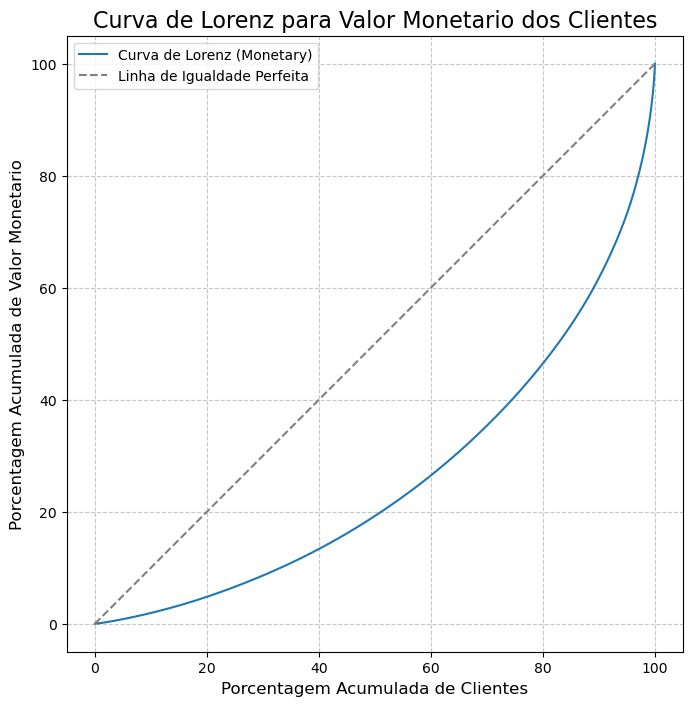

Coeficiente de Gini para Valor Monetario: 0.4786
Desigualdade moderada a alta.


In [11]:
# Curva de Lorenz e Coeficiente de Gini
lorenz_df = lorenz_curve(rfm["Monetary"])
perfect_equality = pd.DataFrame(
    {
        "cumulative_customers_pct": [0, 100],
        "cumulative_monetary_pct": [0, 100],
    }
)

plt.figure(figsize=(10, 8))
plt.plot(
    lorenz_df["cumulative_customers_pct"],
    lorenz_df["cumulative_monetary_pct"],
    label="Curva de Lorenz (Monetary)",
)
plt.plot(
    perfect_equality["cumulative_customers_pct"],
    perfect_equality["cumulative_monetary_pct"],
    linestyle="--",
    color="grey",
    label="Linha de Igualdade Perfeita",
)
plt.title("Curva de Lorenz para Valor Monetario dos Clientes", fontsize=16)
plt.xlabel("Porcentagem Acumulada de Clientes", fontsize=12)
plt.ylabel("Porcentagem Acumulada de Valor Monetario", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle="--", alpha=0.7)
plt.gca().set_aspect("equal", adjustable="box")
plt.show()

# Coeficiente de Gini
gini = gini_coefficient(rfm["Monetary"])
print(f"Coeficiente de Gini para Valor Monetario: {gini:.4f}")
if gini > 0.5:
    print("Alta desigualdade na distribuicao do valor monetario.")
elif gini > 0.3:
    print("Desigualdade moderada a alta.")
else:
    print("Baixa desigualdade.")


### Leitura da Curva de Lorenz e do Coeficiente de Gini

A curva se afasta de forma acentuada da linha de igualdade perfeita, especialmente na parte superior: os primeiros 80% dos clientes contribuem com bem menos do que 80% do valor monetário, enquanto os últimos 20% concentram a maior parte da receita.

O Coeficiente de Gini de **0.4786** confirma uma desigualdade moderada a alta na distribuição do valor entre clientes, corroborando a assimetria já observada na estatística descritiva de Monetary.

Implicação para a segmentação: a base segue o padrão clássico de Pareto, em que a retenção dos clientes de maior valor tem impacto desproporcional na receita. Esse grupo precisa ser isolado e priorizado — exatamente o papel das etapas de segmentação estratégica e clusterização a seguir.

# RFM Score

In [12]:
# Scores R, F, M e segmentos classicos
rfm = apply_rfm_scores(rfm, q=CONFIG["rfm"]["q_score"])

print("Top 10 buckets (volume):")
print(rfm["RFM_bucket"].value_counts().head(10))
print("\nDistribuicao de segmentos:")
print(rfm["RFM_segment"].value_counts())


2026-05-10 17:28:51 | src.segmentation | INFO | RFM scores aplicados. Segmentos:
RFM_segment
Others                           38869
At Risk                          23234
Loyal Customers                   7436
Champions                         6513
Big Spenders (New/Occasional)     6041
Potential Loyalists               6004
New Customers                     4464
Lost                               797


Top 10 buckets (volume):
RFM_bucket
555    1009
455     962
255     893
355     883
222     854
155     848
424     843
531     840
242     838
131     823
Name: count, dtype: int64

Distribuicao de segmentos:
RFM_segment
Others                           38869
At Risk                          23234
Loyal Customers                   7436
Champions                         6513
Big Spenders (New/Occasional)     6041
Potential Loyalists               6004
New Customers                     4464
Lost                               797
Name: count, dtype: int64



## 4) EDA da base analítica RFM
Nesta etapa, analisamos a distribuição e o comportamento das métricas de Recency, Frequency e Monetary para entender a estrutura da base de clientes antes da segmentação.



## 4.1 Análise univariada
Nesta etapa, analisamos cada métrica do RFM de forma isolada para entender distribuição,
assimetria, presença de outliers e comportamento geral da base.

### 4.1.1 KPIs iniciais

In [13]:
n_clientes = rfm.shape[0]
recency_media = rfm["Recency"].mean()
frequency_media = rfm["Frequency"].mean()
monetary_medio = rfm["Monetary"].mean()

clientes_1_compra = (rfm["Frequency"] == 1).sum()
pct_1_compra = clientes_1_compra / n_clientes

clientes_recorrentes = (rfm["Frequency"] > 1).sum()
pct_recorrentes = clientes_recorrentes / n_clientes

print(f"Números de Clientes na base RFM: {n_clientes:,}")
print(f"Recency média: {recency_media:.2f} dias")
print(f"Frequency média: {frequency_media:.2f}")
print(f"Monetary médio: R$ {monetary_medio:,.2f}")
print(f"Número de Clientes com 1 compra: {clientes_1_compra:,} ({pct_1_compra:.2%})")
print(f"Clientes recorrentes (>1 compra): {clientes_recorrentes:,} ({pct_recorrentes:.2%})")


Números de Clientes na base RFM: 93,358
Recency média: 242.48 dias
Frequency média: 1.03
Monetary médio: R$ 165.20
Número de Clientes com 1 compra: 90,557 (97.00%)
Clientes recorrentes (>1 compra): 2,801 (3.00%)


### 4.1.2 Estatística descritiva

In [14]:
import pandas as pd

stats_rfm = (
    rfm[["Recency", "Frequency", "Monetary"]]
    .agg(["count", "mean", "median", "std", "min", "max", "skew"])
    .T
)

stats_rfm


,count,mean,median,std,min,max,skew
Recency,93358.0,242.478888,223.00,152.595050,5.00,718.00,0.447487
Frequency,93358.0,1.033420,1.00,0.209097,1.00,15.00,11.095156
Monetary,93358.0,165.198448,107.78,226.313388,9.59,13664.08,9.211042


### 4.1.3 Histogramas

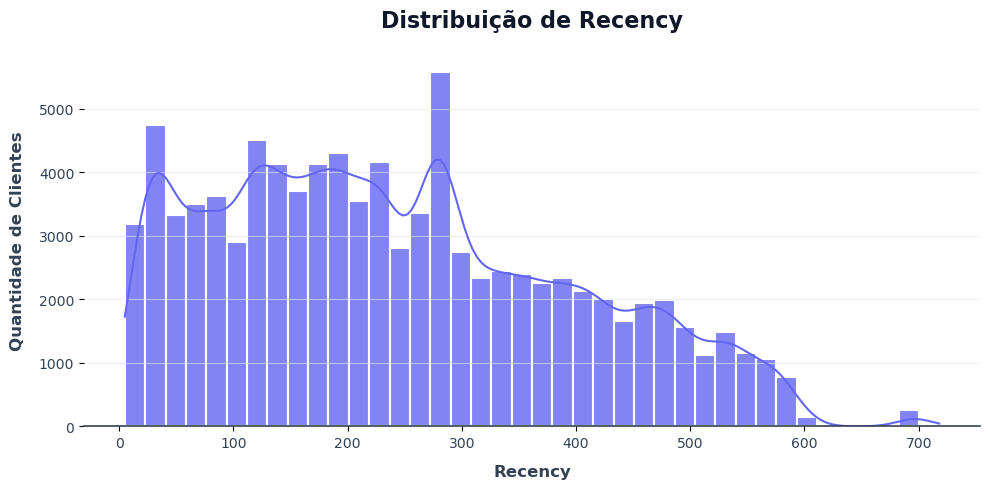

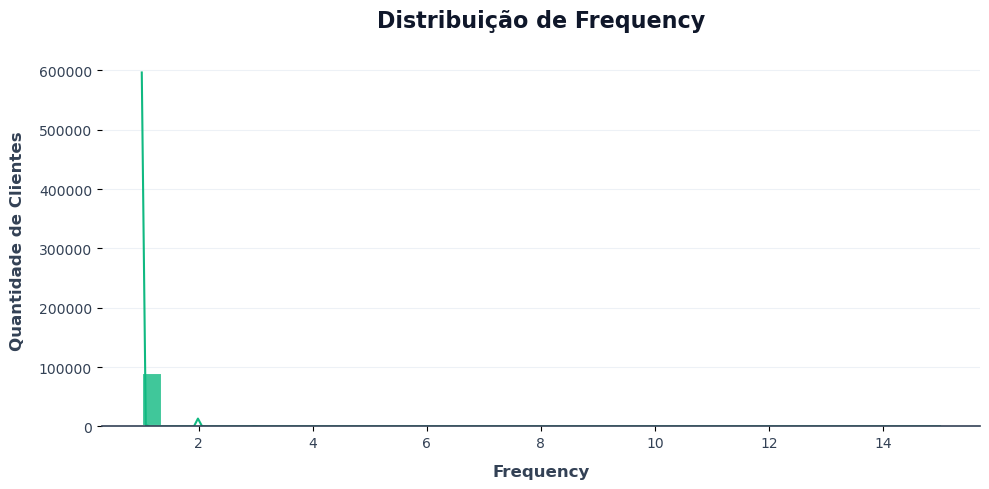

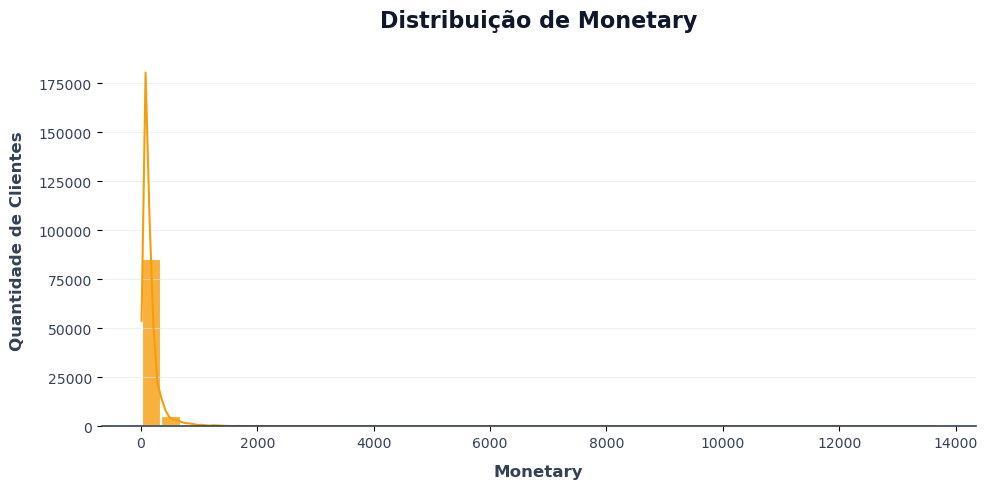

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Paleta de alto contraste
TITLE_COLOR = "#0F172A"  # Slate 900 (Quase preto para contraste total)
LABEL_COLOR = "#334155"  # Slate 700 (Cinza escuro para leitura clara)
GRID_COLOR = "#E2E8F0"  # Cinza leve para o fundo

colors = {"Recency": "#6366F1", "Frequency": "#10B981", "Monetary": "#F59E0B"}

for col in ["Recency", "Frequency", "Monetary"]:
    plt.figure(figsize=(10, 5), dpi=100)

    # Histograma com barras levemente mais sólidas (alpha=0.8)
    ax = sns.histplot(
        rfm[col].dropna(),
        bins=40,
        color=colors[col],
        kde=True,
        edgecolor="white",
        linewidth=1.5,
        alpha=0.8,
    )

    # Título com contraste máximo
    plt.title(f"Distribuição de {col}", fontsize=16, pad=20, weight="bold", color=TITLE_COLOR)

    # Eixos bem visíveis
    plt.xlabel(col, fontsize=12, labelpad=10, color=LABEL_COLOR, weight="600")
    plt.ylabel("Quantidade de Clientes", fontsize=12, labelpad=10, color=LABEL_COLOR, weight="600")

    # Grid horizontal um pouco mais presente para facilitar a leitura
    ax.yaxis.grid(True, linestyle="-", color=GRID_COLOR, alpha=0.6)
    ax.xaxis.grid(False)

    # Linha do eixo X reforçada para ancorar o gráfico
    ax.spines["bottom"].set_color(LABEL_COLOR)
    ax.spines["bottom"].set_linewidth(1.2)

    sns.despine(left=True, bottom=False)

    # Números dos eixos em cor escura
    plt.xticks(color=LABEL_COLOR, weight="500")
    plt.yticks(color=LABEL_COLOR, weight="500")

    plt.tight_layout()
    plt.show()


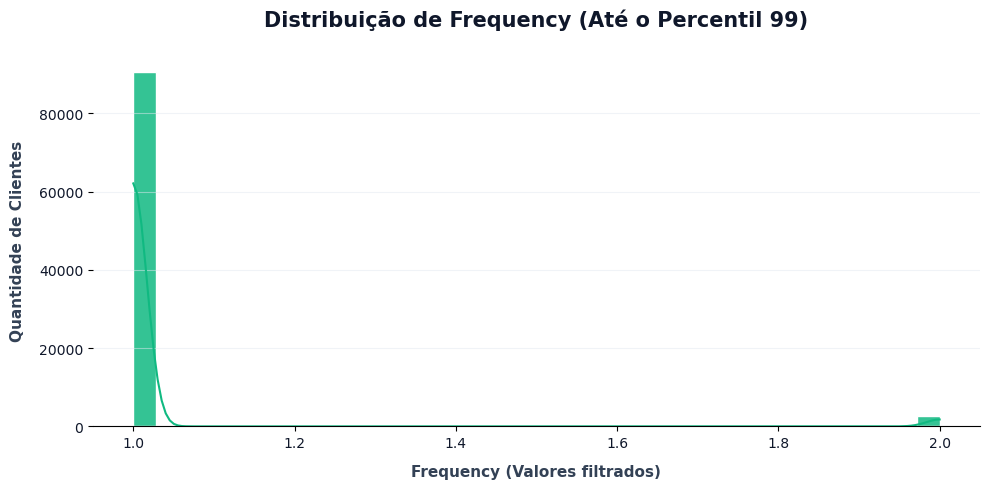

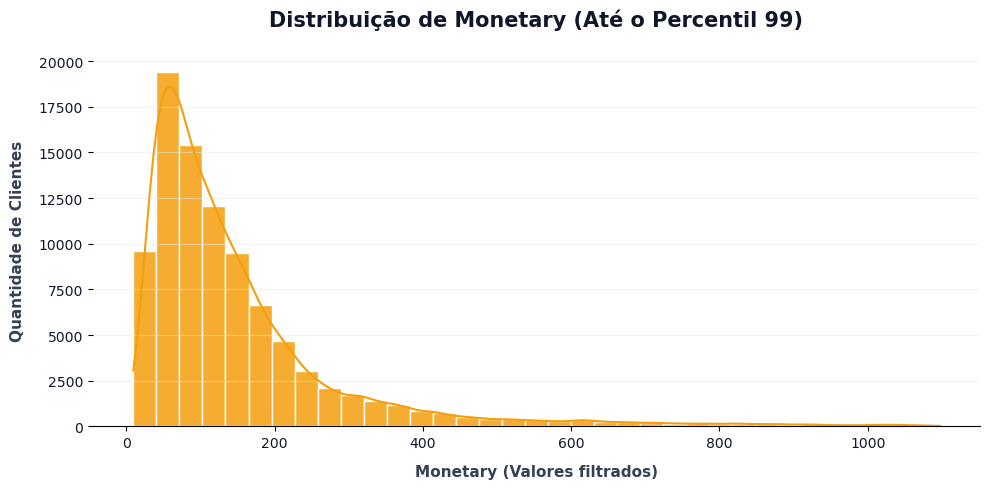

In [16]:
# Configurações de cores de alto contraste
TITLE_COLOR = "#0F172A"
LABEL_COLOR = "#334155"
GRID_COLOR = "#E2E8F0"

# Paleta por métrica
colors = {"Frequency": "#10B981", "Monetary": "#F59E0B"}

for col in ["Frequency", "Monetary"]:
    plt.figure(figsize=(10, 5), dpi=100)

    # Zoom no intervalo relevante
    # Filtramos os dados para mostrar apenas até o percentil 99
    # Isso remove os "outliers" que esticam o gráfico desnecessariamente
    data_filtered = rfm[col].dropna()
    upper_limit = data_filtered.quantile(0.99)
    plot_data = data_filtered[data_filtered <= upper_limit]

    # Criando o gráfico
    ax = sns.histplot(
        plot_data, bins=35, color=colors[col], kde=True, edgecolor="white", linewidth=1, alpha=0.85
    )

    # Títulos e Labels com alto contraste
    plt.title(
        f"Distribuição de {col} (Até o Percentil 99)",
        fontsize=15,
        pad=20,
        weight="bold",
        color=TITLE_COLOR,
    )
    plt.xlabel(
        f"{col} (Valores filtrados)", fontsize=11, labelpad=10, color=LABEL_COLOR, weight="bold"
    )
    plt.ylabel("Quantidade de Clientes", fontsize=11, labelpad=10, color=LABEL_COLOR, weight="bold")

    # Ajustes finos de UI
    ax.yaxis.grid(True, linestyle="-", color=GRID_COLOR, alpha=0.5)
    sns.despine(left=True)

    plt.xticks(color=TITLE_COLOR, weight="500")
    plt.yticks(color=TITLE_COLOR, weight="500")

    plt.tight_layout()
    plt.show()


### 4.1.4 Box plots


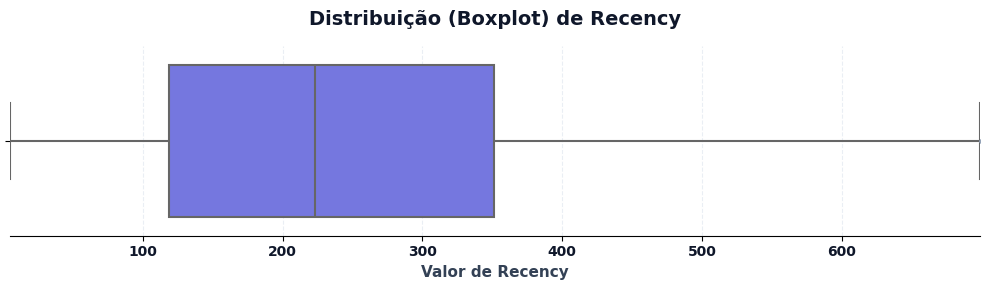

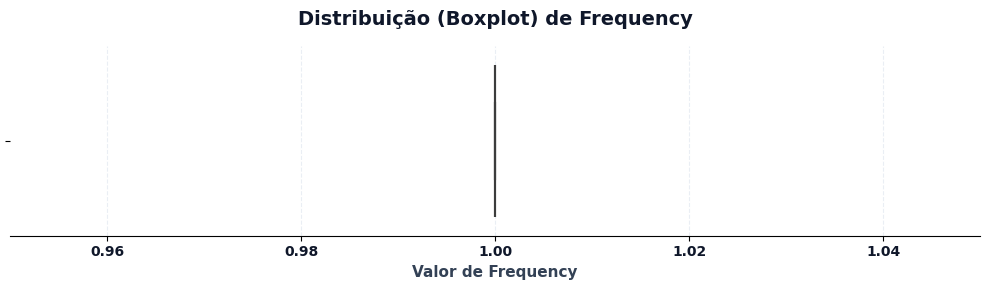

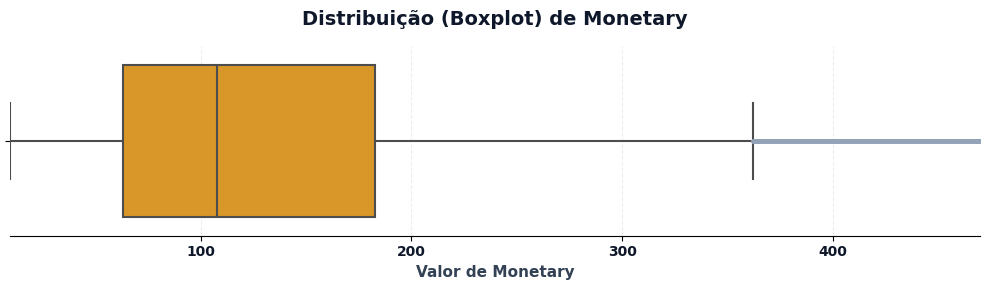

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de cores de alto contraste (Nítidas)
TITLE_COLOR = "#0F172A"
LABEL_COLOR = "#334155"
GRID_COLOR = "#E2E8F0"

# Cores para cada métrica
colors = {
    "Recency": "#6366F1",  # Indigo
    "Frequency": "#10B981",  # Emerald
    "Monetary": "#F59E0B",  # Amber
}

for col in ["Recency", "Frequency", "Monetary"]:
    plt.figure(figsize=(10, 3), dpi=100)

    # Criando o Boxplot com Seaborn para melhor estética
    # fliersize=4 diminui o tamanho dos pontos de outlier para não poluir
    ax = sns.boxplot(
        x=rfm[col].dropna(),
        color=colors[col],
        linewidth=1.5,
        fliersize=3,
        flierprops={"markerfacecolor": "#94A3B8", "markeredgecolor": "none", "alpha": 0.5},
    )

    # Zoom no intervalo relevante
    # Para o Boxplot, vamos focar a visão até um pouco além do limite superior (Whisker)
    data = rfm[col].dropna()
    q3 = data.quantile(0.75)
    q1 = data.quantile(0.25)
    iqr = q3 - q1
    upper_limit = q3 + (1.5 * iqr)  # Limite estatístico de outliers

    # Ajustamos o limite do gráfico para o maior valor entre o limite estatístico ou o percentil 95
    # Isso garante que a "caixa" apareça grande, mas ainda vejamos alguns outliers
    plot_limit = max(upper_limit, data.quantile(0.95))
    plt.xlim(data.min(), plot_limit)

    # Títulos e labels
    plt.title(
        f"Distribuição (Boxplot) de {col}", fontsize=14, pad=15, weight="bold", color=TITLE_COLOR
    )
    plt.xlabel(f"Valor de {col}", fontsize=11, weight="bold", color=LABEL_COLOR)

    # Customização de UI
    ax.xaxis.grid(True, linestyle="--", color=GRID_COLOR, alpha=0.7)
    sns.despine(left=True)

    # Escurecendo os números dos eixos
    plt.xticks(color=TITLE_COLOR, weight="600")

    plt.tight_layout()
    plt.show()


### 4.1.5 Distribuições de frequência

In [18]:
# Criando a distribuição
freq_dist = rfm["Frequency"].value_counts().sort_index().reset_index()
freq_dist.columns = ["Frequency", "Qtd_Clientes"]

# Cálculos de Percentual e Acumulado
freq_dist["Pct_Clientes"] = freq_dist["Qtd_Clientes"] / freq_dist["Qtd_Clientes"].sum()
freq_dist["Pct_Acumulado"] = freq_dist["Pct_Clientes"].cumsum()

# Formatação
freq_dist.head(10).style.format(
    {"Pct_Clientes": "{:.2%}", "Pct_Acumulado": "{:.2%}", "Qtd_Clientes": "{:,.0f}"}
)


,Frequency,Qtd_Clientes,Pct_Clientes,Pct_Acumulado
0,1,"90,557",97.00%,97.00%
1,2,"2,573",2.76%,99.76%
2,3,181,0.19%,99.95%
3,4,28,0.03%,99.98%
4,5,9,0.01%,99.99%
5,6,5,0.01%,99.99%
6,7,3,0.00%,100.00%
7,9,1,0.00%,100.00%
8,15,1,0.00%,100.00%


2026-05-10 17:28:56 | matplotlib.category | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-10 17:28:56 | matplotlib.category | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


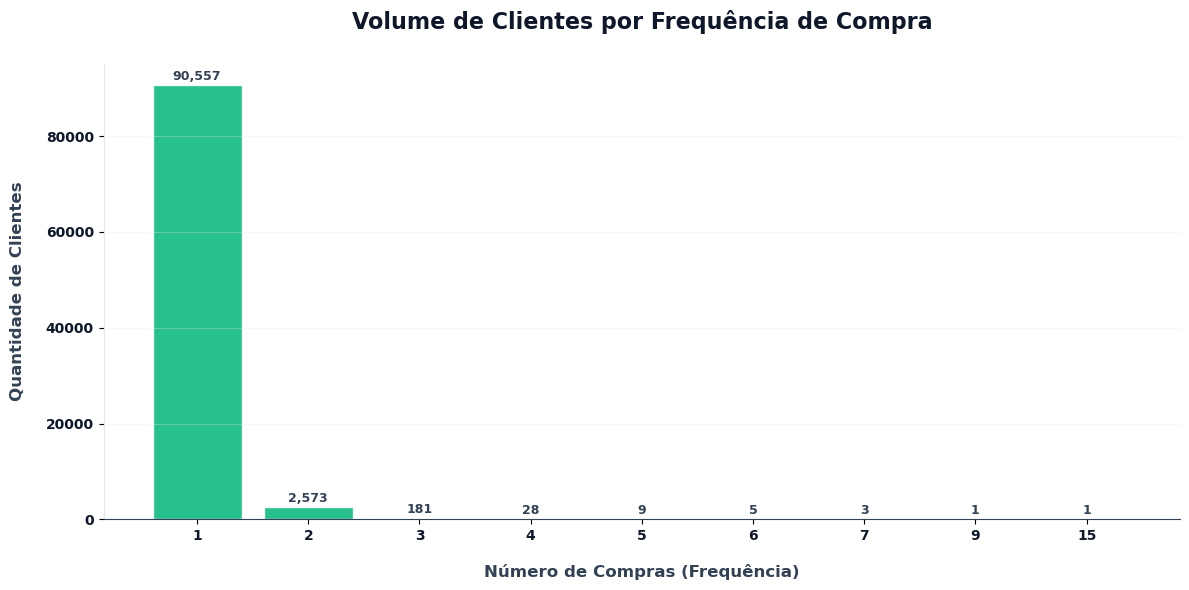

In [19]:
import matplotlib.pyplot as plt

# Cores de alto contraste
TITLE_COLOR = "#0F172A"
LABEL_COLOR = "#334155"
BAR_COLOR = "#10B981"  # Emerald
GRID_COLOR = "#E2E8F0"

plt.figure(figsize=(12, 6), dpi=100)

# Mostra apenas as 15 frequências mais comuns para não poluir o gráfico
# Geralmente, após 10 ou 15 compras, a quantidade de clientes é muito pequena
df_plot = freq_dist.head(15).copy()

# Criando as barras com bordas arredondadas (simuladas por largura e alinhamento)
bars = plt.bar(
    df_plot["Frequency"].astype(str),
    df_plot["Qtd_Clientes"],
    color=BAR_COLOR,
    edgecolor="white",
    linewidth=1,
    alpha=0.9,
)

# Adicionando rótulos de dados no topo de cada barra (Data Labels)
# Isso ajuda a ler o valor exato sem precisar olhar o eixo Y
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 500,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
        color=LABEL_COLOR,
        weight="bold",
    )

# Títulos e labels
plt.title(
    "Volume de Clientes por Frequência de Compra",
    fontsize=16,
    pad=25,
    weight="bold",
    color=TITLE_COLOR,
)
plt.xlabel(
    "Número de Compras (Frequência)", fontsize=12, labelpad=15, color=LABEL_COLOR, weight="bold"
)
plt.ylabel("Quantidade de Clientes", fontsize=12, labelpad=15, color=LABEL_COLOR, weight="bold")

# Refinamento de Grade e Eixos
plt.grid(axis="y", linestyle="-", alpha=0.3, color=GRID_COLOR)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_color(GRID_COLOR)
plt.gca().spines["bottom"].set_color(LABEL_COLOR)

# Escurecendo os números dos eixos
plt.xticks(color=TITLE_COLOR, weight="600")
plt.yticks(color=TITLE_COLOR, weight="600")

plt.tight_layout()
plt.show()


In [20]:
freq_summary = pd.DataFrame(
    {
        "Grupo": ["1 compra", "2+ compras", "3+ compras"],
        "Qtd_Clientes": [
            (rfm["Frequency"] == 1).sum(),
            (rfm["Frequency"] >= 2).sum(),
            (rfm["Frequency"] >= 3).sum(),
        ],
    }
)

freq_summary["Pct_Clientes"] = freq_summary["Qtd_Clientes"] / len(rfm)
freq_summary


,Grupo,Qtd_Clientes,Pct_Clientes
0,1 compra,90557,0.969997
1,2+ compras,2801,0.030003
2,3+ compras,228,0.002442


### 4.1.6 Distribuição de recência

In [21]:
bins_recency = [-1, 30, 90, 180, 365, rfm["Recency"].max()]
labels_recency = ["0-30", "31-90", "91-180", "181-365", "365+"]

rfm["Recency_Faixa"] = pd.cut(rfm["Recency"], bins=bins_recency, labels=labels_recency)

recency_faixa = rfm["Recency_Faixa"].value_counts().sort_index().reset_index()
recency_faixa.columns = ["Faixa_Recency", "Qtd_Clientes"]
recency_faixa["Pct_Clientes"] = recency_faixa["Qtd_Clientes"] / recency_faixa["Qtd_Clientes"].sum()

recency_faixa


,Faixa_Recency,Qtd_Clientes,Pct_Clientes
0,0-30,5408,0.057928
1,31-90,12264,0.131365
2,91-180,19383,0.207620
3,181-365,34950,0.374365
4,365+,21353,0.228722


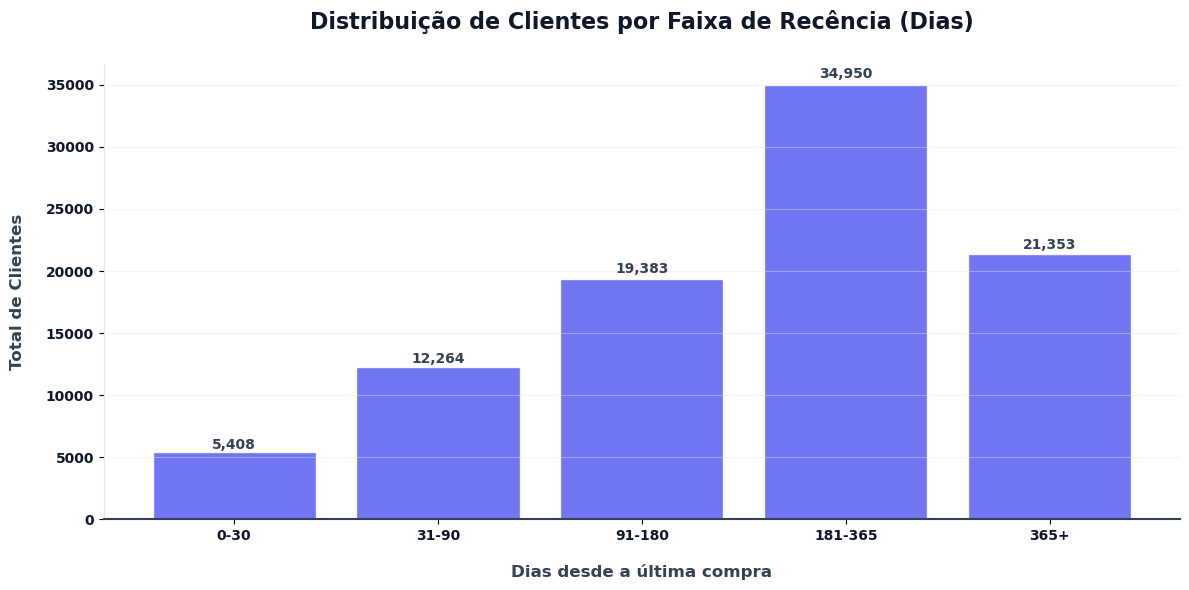

In [22]:
import matplotlib.pyplot as plt

# Cores High Contrast (Slate 900 e 700 para leitura perfeita)
TITLE_COLOR = "#0F172A"
LABEL_COLOR = "#334155"
BAR_COLOR = "#6366F1"  # Indigo Pro
GRID_COLOR = "#E2E8F0"

plt.figure(figsize=(12, 6), dpi=100)

# Criando as barras
# Faixas convertidas para string para garantir a ordem correta no eixo X
bars = plt.bar(
    recency_faixa["Faixa_Recency"].astype(str),
    recency_faixa["Qtd_Clientes"],
    color=BAR_COLOR,
    edgecolor="white",
    linewidth=1,
    alpha=0.9,
)

# Adicionando Data Labels (Valores acima das barras)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + (height * 0.01),
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        color=LABEL_COLOR,
        weight="bold",
    )

# Títulos e Eixos com contraste reforçado
plt.title(
    "Distribuição de Clientes por Faixa de Recência (Dias)",
    fontsize=16,
    pad=25,
    weight="bold",
    color=TITLE_COLOR,
)
plt.xlabel("Dias desde a última compra", fontsize=12, labelpad=15, color=LABEL_COLOR, weight="bold")
plt.ylabel("Total de Clientes", fontsize=12, labelpad=15, color=LABEL_COLOR, weight="bold")

# Refinamento de Grid e Spines (Bordas)
plt.grid(axis="y", linestyle="-", alpha=0.4, color=GRID_COLOR)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_color(GRID_COLOR)
plt.gca().spines["bottom"].set_color(LABEL_COLOR)
plt.gca().spines["bottom"].set_linewidth(1.5)

# Escurecendo os ticks dos eixos para visibilidade máxima
plt.xticks(color=TITLE_COLOR, weight="700", rotation=0)  # Rotação 0 para leitura direta
plt.yticks(color=TITLE_COLOR, weight="700")

plt.tight_layout()
plt.show()


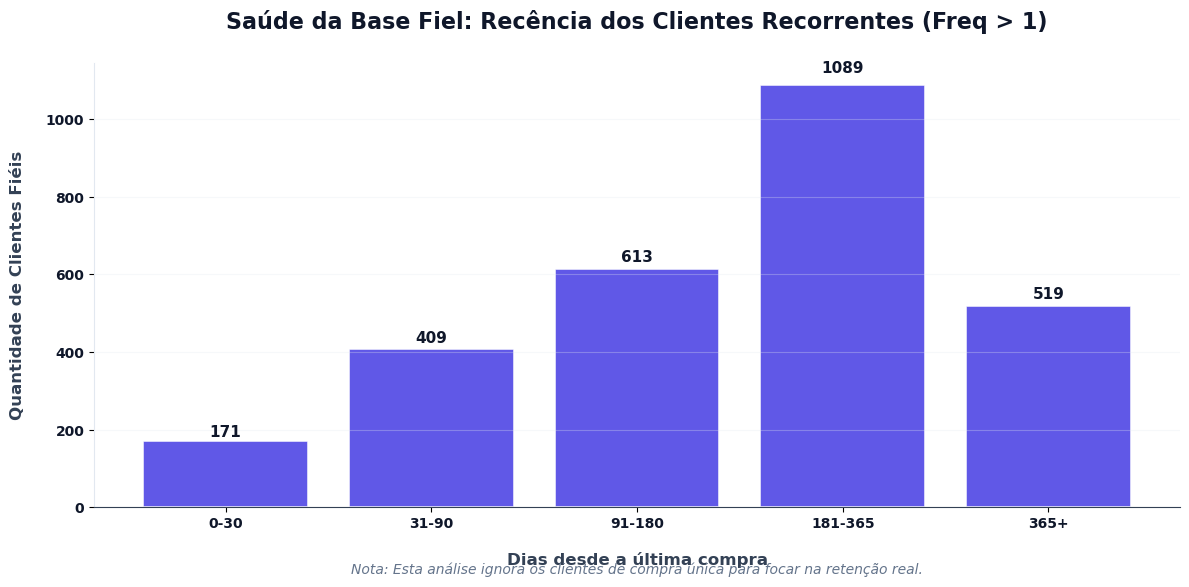

In [23]:
df_recorrente = rfm[rfm["Frequency"] > 1].copy()

# Definindo as faixas (Bins) de Recência
bins = [0, 30, 90, 180, 365, rfm["Recency"].max()]
labels = ["0-30", "31-90", "91-180", "181-365", "365+"]

df_recorrente["Faixa_Recency"] = pd.cut(df_recorrente["Recency"], bins=bins, labels=labels)

# Agrupando para o gráfico
dist_fiel = df_recorrente["Faixa_Recency"].value_counts().sort_index().reset_index()
dist_fiel.columns = ["Faixa_Recency", "Qtd_Clientes"]

# Colors
TITLE_COLOR = "#0F172A"
LABEL_COLOR = "#334155"
BAR_COLOR = "#4F46E5"
GRID_COLOR = "#E2E8F0"

plt.figure(figsize=(12, 6), dpi=100)

# Criando as barras
bars = plt.bar(
    dist_fiel["Faixa_Recency"].astype(str),
    dist_fiel["Qtd_Clientes"],
    color=BAR_COLOR,
    edgecolor="white",
    linewidth=1.2,
    alpha=0.9,
)

# Adicionando Data Labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + (height * 0.02),
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=11,
        color=TITLE_COLOR,
        weight="bold",
    )

# Títulos e Labels com Contraste Reforçado
plt.title(
    "Saúde da Base Fiel: Recência dos Clientes Recorrentes (Freq > 1)",
    fontsize=16,
    pad=25,
    weight="bold",
    color=TITLE_COLOR,
)
plt.xlabel("Dias desde a última compra", fontsize=12, labelpad=15, color=LABEL_COLOR, weight="bold")
plt.ylabel(
    "Quantidade de Clientes Fiéis", fontsize=12, labelpad=15, color=LABEL_COLOR, weight="bold"
)

# Refinamento de Grade e Eixos
plt.grid(axis="y", linestyle="-", alpha=0.3, color=GRID_COLOR)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_color(GRID_COLOR)
plt.gca().spines["bottom"].set_color(LABEL_COLOR)

# Ticks (Números dos eixos) bem visíveis
plt.xticks(color=TITLE_COLOR, weight="700")
plt.yticks(color=TITLE_COLOR, weight="700")

# Legenda ou anotação de Insight
plt.text(
    0.5,
    -0.15,
    f"Nota: Esta análise ignora os clientes de compra única para focar na retenção real.",
    transform=plt.gca().transAxes,
    ha="center",
    color="#64748B",
    fontsize=10,
    style="italic",
)

plt.tight_layout()
plt.show()


### Insights de recência

A análise comparativa de recência entre a base total (N ≈ 93k) e o grupo de clientes recorrentes (N ≈ 2.8k) revela um padrão de **churn sistêmico**: a similaridade das curvas de abandono indica que a inatividade independe do histórico de compra, sugerindo falha na manutenção do relacionamento pós-conversão.

**Pontos de atenção**
* **Uniformidade de abandono:** o volume máximo de clientes (novos e recorrentes) concentra-se na janela de **181 a 365 dias** de inatividade. A base recorrente não possui barreira de saída (lock-in) superior à dos clientes de compra única.
* **Vulnerabilidade do ativo fiel:** apenas **7,6%** da base recorrente (213 de 2.801) realizou transações nos últimos 30 dias — o segmento de maior LTV está subutilizado.

**Diagnóstico**
1. **Atrito pós-consumo:** o declínio uniforme indica que o desinteresse ocorre por obsolescência do contato, e não necessariamente por insatisfação pontual.
2. **Inexistência de régua de reativação:** sem gatilhos de recompra, clientes validados entram em dormência no mesmo ritmo que clientes experimentais.

**Priorização de ações**
* **Prioridade 1 (recuperação):** focar no grupo de **1.069 clientes recorrentes** na faixa de 181-365 dias — o custo de reativação é significativamente menor que o CAC de novos clientes.
* **Prioridade 2 (prevenção):** réguas de comunicação para os **621 clientes recorrentes** na faixa de 91-180 dias, revertendo a tendência antes do estágio crítico de churn.
* **Prioridade 3 (fidelização):** benefícios exclusivos para os **213 clientes ativos** (0-30 dias), aumentando frequência e reduzindo a volatilidade da base.

O objetivo imediato é deslocar o centro de gravidade da curva de recência — hoje acima de 180 dias — para a janela de 0-90 dias, garantindo previsibilidade de receita e sustentabilidade da base ativa.

### 4.1.7 Faixas monetárias

In [24]:
rfm["Monetary_Faixa"] = pd.qcut(
    rfm["Monetary"],
    q=5,
    labels=["Muito Baixo", "Baixo", "Médio", "Alto", "Muito Alto"],
    duplicates="drop",
)

monetary_faixa = rfm["Monetary_Faixa"].value_counts().sort_index().reset_index()
monetary_faixa.columns = ["Faixa_Monetary", "Qtd_Clientes"]
monetary_faixa["Pct_Clientes"] = (
    monetary_faixa["Qtd_Clientes"] / monetary_faixa["Qtd_Clientes"].sum()
)

monetary_faixa


,Faixa_Monetary,Qtd_Clientes,Pct_Clientes
0,Muito Baixo,18673,0.200015
1,Baixo,18683,0.200122
2,Médio,18660,0.199876
3,Alto,18674,0.200026
4,Muito Alto,18668,0.199961


## 4.2 Concentração de receita
Além da análise individual das métricas, esta etapa avalia o nível de concentração da receita na base de clientes, verificando se uma parcela reduzida da base concentra grande parte do valor gerado.


In [25]:
pareto = rfm[["customer_unique_id", "Monetary"]].copy()
pareto = pareto.sort_values("Monetary", ascending=False).reset_index(drop=True)
pareto["Receita_Acumulada"] = pareto["Monetary"].cumsum()
pareto["Pct_Receita_Acumulada"] = pareto["Receita_Acumulada"] / pareto["Monetary"].sum()
pareto["Pct_Clientes_Acumulada"] = (pareto.index + 1) / len(pareto)

pareto.head()


,customer_unique_id,Monetary,Receita_Acumulada,Pct_Receita_Acumulada,Pct_Clientes_Acumulada
0,0a0a92112bd4c708ca5fde585afaa872,13664.08,13664.08,0.000886,0.000011
1,da122df9eeddfedc1dc1f5349a1a690c,7571.63,21235.71,0.001377,0.000021
2,763c8b1c9c68a0229c42c9fc6f662b93,7274.88,28510.59,0.001849,0.000032
3,dc4802a71eae9be1dd28f5d788ceb526,6929.31,35439.90,0.002298,0.000043
4,459bef486812aa25204be022145caa62,6922.21,42362.11,0.002747,0.000054


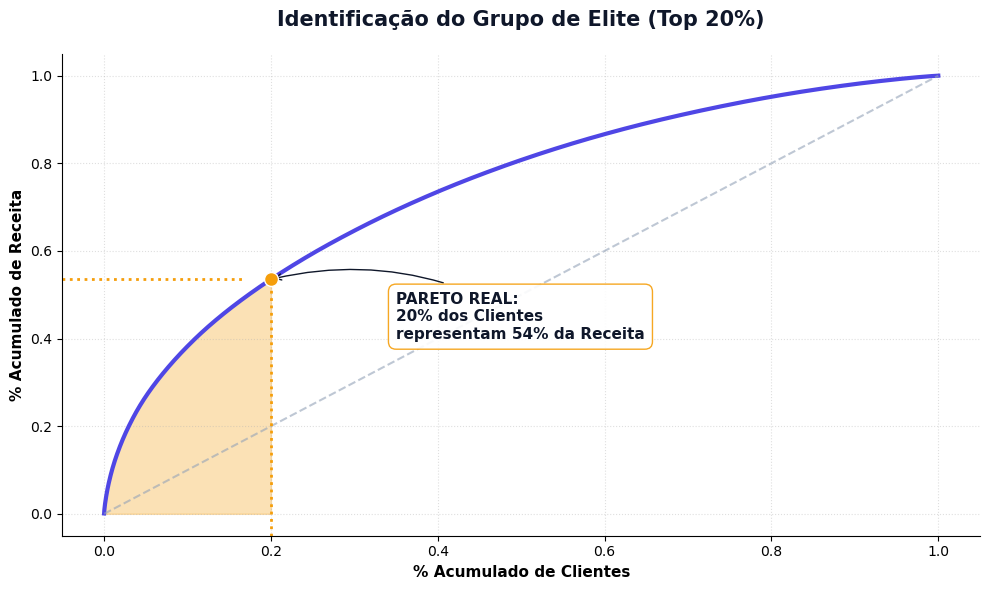

In [26]:
import matplotlib.pyplot as plt

# Cores Corporativas
ACCENT_COLOR = "#4F46E5"
HIGHLIGHT_COLOR = "#F59E0B"  # Cor de destaque (Âmbar) para o Pareto
TITLE_COLOR = "#0F172A"

plt.figure(figsize=(10, 6), dpi=100)

# 1. Curva Principal
plt.plot(
    pareto["Pct_Clientes_Acumulada"],
    pareto["Pct_Receita_Acumulada"],
    color=ACCENT_COLOR,
    linewidth=3,
    label="Curva de Lorenz",
)

# 2. Linha de Igualdade
plt.plot([0, 1], [0, 1], linestyle="--", color="#94A3B8", alpha=0.6)

# --- DEMARCAÇÃO DO TOP 20% (PARETO) ---
# Encontrando o valor exato de receita para 20% de clientes
receita_20 = pareto.iloc[(pareto["Pct_Clientes_Acumulada"] - 0.2).abs().argsort()[:1]][
    "Pct_Receita_Acumulada"
].values[0]

# Linhas de projeção (os "tracejados" que ligam os eixos)
plt.axvline(x=0.2, ymin=0, ymax=receita_20, color=HIGHLIGHT_COLOR, linestyle=":", linewidth=2)
plt.axhline(y=receita_20, xmin=0, xmax=0.2, color=HIGHLIGHT_COLOR, linestyle=":", linewidth=2)

# Ponto de destaque
plt.scatter(0.2, receita_20, color=HIGHLIGHT_COLOR, s=100, zorder=5, edgecolor="white")

# Preenchimento apenas da área vital (Top 20%)
plt.fill_between(
    pareto["Pct_Clientes_Acumulada"],
    0,
    pareto["Pct_Receita_Acumulada"],
    where=(pareto["Pct_Clientes_Acumulada"] <= 0.2),
    color=HIGHLIGHT_COLOR,
    alpha=0.3,
    label="Área de Concentração (Top 20%)",
)

# 3. Anotação de Texto no Gráfico
plt.annotate(
    f"PARETO REAL:\n20% dos Clientes\nrepresentam {receita_20:.0%} da Receita",
    xy=(0.2, receita_20),
    xytext=(0.35, 0.4),
    arrowprops=dict(arrowstyle="->", color=TITLE_COLOR, connectionstyle="arc3,rad=.2"),
    fontsize=11,
    fontweight="bold",
    color=TITLE_COLOR,
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec=HIGHLIGHT_COLOR, alpha=0.9),
)

# Estética Final
plt.title(
    "Identificação do Grupo de Elite (Top 20%)",
    fontsize=15,
    pad=20,
    weight="bold",
    color=TITLE_COLOR,
)
plt.xlabel("% Acumulado de Clientes", fontsize=11, weight="bold")
plt.ylabel("% Acumulado de Receita", fontsize=11, weight="bold")
plt.grid(True, linestyle=":", alpha=0.4)
sns.despine()

plt.tight_layout()
plt.show()


### 4.2.1 Share do top 10% e top 20%

In [27]:
top_10_cut = int(len(pareto) * 0.10)
share_top_10 = pareto.iloc[:top_10_cut]["Monetary"].sum() / pareto["Monetary"].sum()

print(f"Top 10% dos clientes concentram {share_top_10:.2%} da receita.")


Top 10% dos clientes concentram 38.25% da receita.


In [28]:
top_20_cut = int(len(pareto) * 0.20)
share_top_20 = pareto.iloc[:top_20_cut]["Monetary"].sum() / pareto["Monetary"].sum()

print(f"Top 20% dos clientes concentram {share_top_20:.2%} da receita.")


Top 20% dos clientes concentram 53.52% da receita.


## 4.3 Análise bivariada
Nesta etapa, analisamos a relação entre as dimensões do RFM para entender como recência, frequência e valor monetário se combinam no comportamento dos clientes.

### 4.3.1 Correlação RFM

In [29]:
corr_rfm = rfm[["Recency", "Frequency", "Monetary"]].corr()
corr_rfm


,Recency,Frequency,Monetary
Recency,1.000000,-0.022260,-0.004396
Frequency,-0.022260,1.000000,0.122072
Monetary,-0.004396,0.122072,1.000000


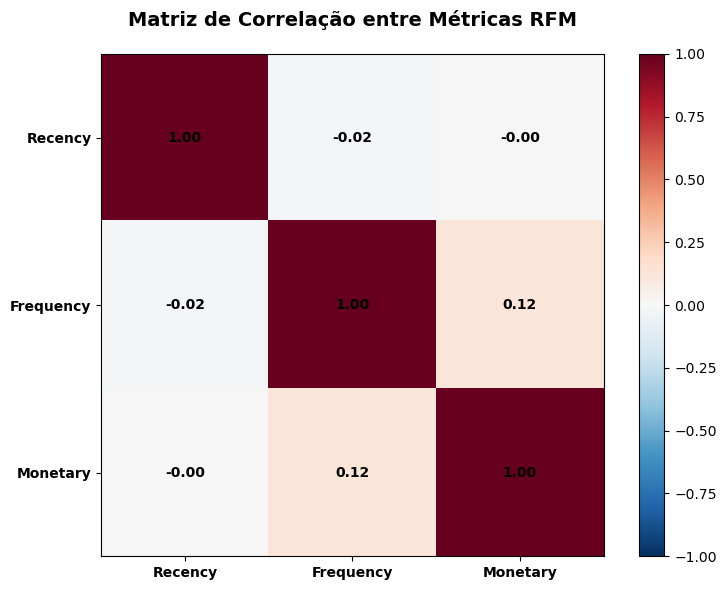

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# cmap='RdBu_r': vermelho para correlacoes negativas e azul para positivas
# vmin=-1 e vmax=1: garante que o centro (branca) seja exatamente 0.00
im = plt.imshow(corr_rfm, interpolation="nearest", cmap="RdBu_r", vmin=-1, vmax=1)

plt.colorbar(im)
plt.xticks(range(len(corr_rfm.columns)), corr_rfm.columns, weight="bold")
plt.yticks(range(len(corr_rfm.index)), corr_rfm.index, weight="bold")
plt.title("Matriz de Correlacao entre Metricas RFM", fontsize=14, pad=20, weight="bold")

# Adicionando os valores numericos sobre as celulas
for i in range(len(corr_rfm.index)):
    for j in range(len(corr_rfm.columns)):
        val = corr_rfm.iloc[i, j]
        plt.text(j, i, f"{val:.2f}", ha="center", va="center", weight="bold")

plt.tight_layout()
plt.show()


### 4.3.2 Scatter Recency x Monetary

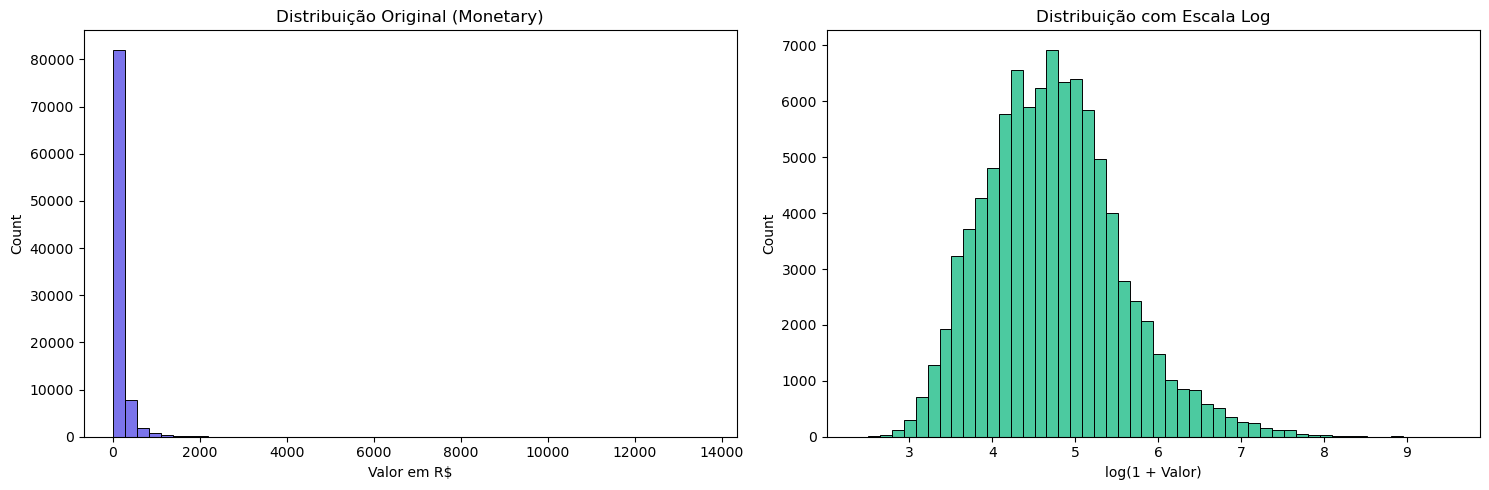

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Histograma da Distribuição Real (Sem Log)
sns.histplot(rfm["Monetary"], bins=50, ax=axes[0], color="#4F46E5")
axes[0].set_title("Distribuição Original (Monetary)")
axes[0].set_xlabel("Valor em R$")

# 2. Histograma com Escala Log
sns.histplot(np.log1p(rfm["Monetary"]), bins=50, ax=axes[1], color="#10B981")
axes[1].set_title("Distribuição com Escala Log")
axes[1].set_xlabel("log(1 + Valor)")

plt.tight_layout()
plt.show()


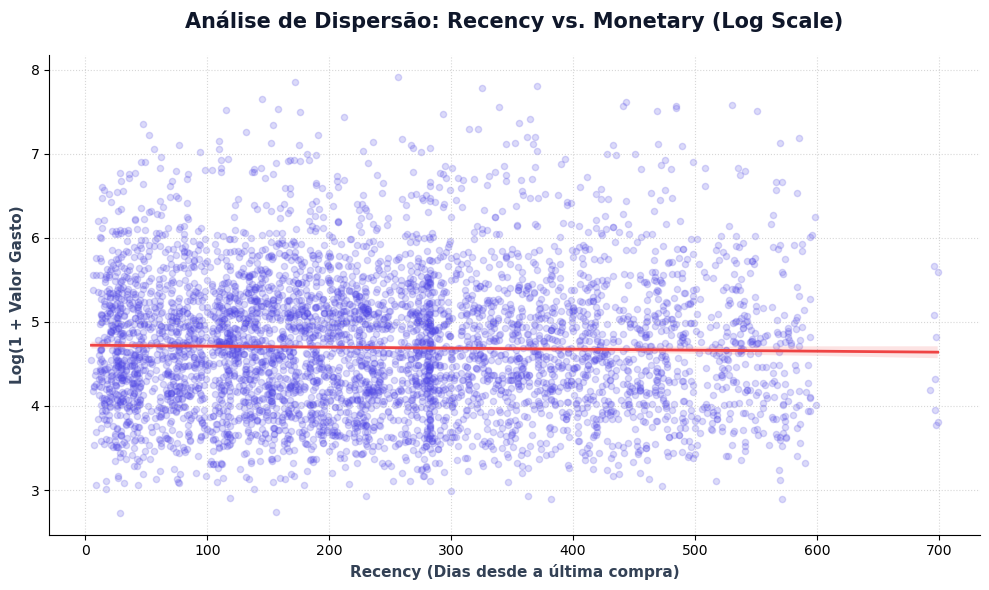

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Preparação dos dados
sample_rfm = rfm.sample(min(5000, len(rfm)), random_state=42).copy()
sample_rfm["Monetary_log"] = np.log1p(sample_rfm["Monetary"])

# 2. Configuração do Gráfico
plt.figure(figsize=(10, 6), dpi=100)

# Utilizando o regplot para adicionar a linha de tendência (regressão linear)
# O parâmetro scatter_kws ajusta a transparência e o tamanho dos pontos
sns.regplot(
    data=sample_rfm,
    x="Recency",
    y="Monetary_log",
    scatter_kws={"alpha": 0.2, "s": 20, "color": "#4F46E5"},
    line_kws={"color": "#EF4444", "lw": 2},  # Linha de tendência em vermelho
    robust=True,
)

# 3. Estética Corporativa
plt.title(
    "Análise de Dispersão: Recency vs. Monetary (Log Scale)",
    fontsize=15,
    pad=20,
    weight="bold",
    color="#0F172A",
)
plt.xlabel("Recency (Dias desde a última compra)", fontsize=11, weight="bold", color="#334155")
plt.ylabel("Log(1 + Valor Gasto)", fontsize=11, weight="bold", color="#334155")

plt.grid(True, linestyle=":", alpha=0.5)
sns.despine()

plt.tight_layout()
plt.show()


A leitura conjunta entre recência e valor indica que parte relevante da base de maior gasto já se encontra em estágios avançados de inatividade. Isso sugere uma oportunidade importante de reativação, especialmente entre clientes que já demonstraram capacidade de gerar maior valor ao longo do tempo.

Do ponto de vista de negócio, esse comportamento reforça que o desafio principal não está apenas em adquirir novos clientes, mas também em recuperar perfis valiosos que deixaram de comprar recentemente.

### 4.3.3 Scatter Frequency x Monetary

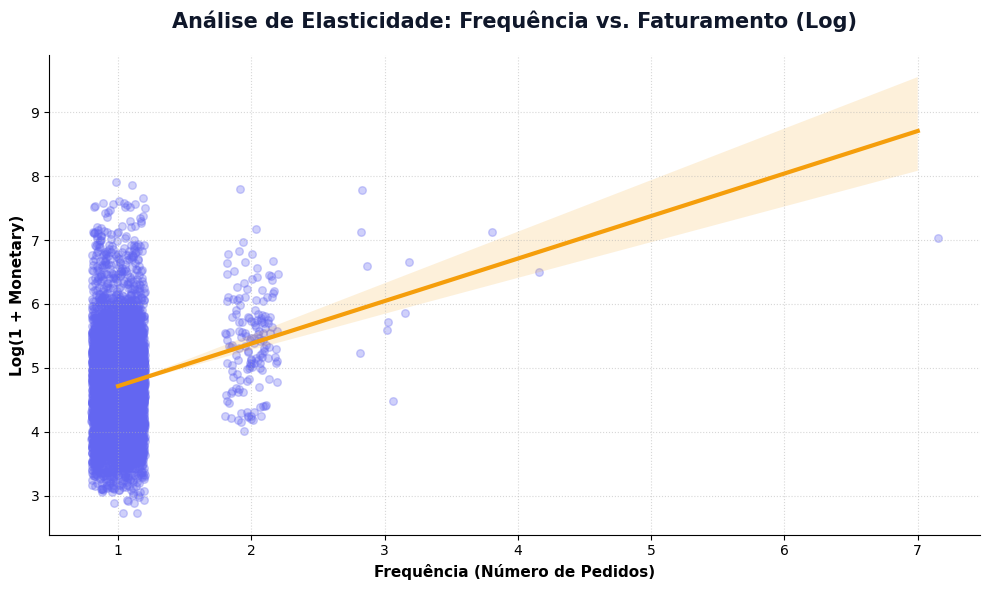

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Preparação: amostragem e transformação log
sample_rfm = rfm.sample(min(5000, len(rfm)), random_state=42).copy()
sample_rfm["Monetary_log"] = np.log1p(sample_rfm["Monetary"])

# 2. Configuração do Gráfico
plt.figure(figsize=(10, 6), dpi=100)

# Usando o regplot para ver a inclinação da receita conforme a frequência sobe
sns.regplot(
    data=sample_rfm,
    x="Frequency",
    y="Monetary_log",
    scatter_kws={"alpha": 0.3, "s": 30, "color": "#6366F1"},
    line_kws={"color": "#F59E0B", "lw": 3},  # Linha de tendência âmbar
    x_jitter=0.2,  # Adiciona um pequeno desvio horizontal para evitar que pontos fiquem 100% sobrepostos em números inteiros
)

# 3. Estética de Relatório
plt.title(
    "Análise de Elasticidade: Frequência vs. Faturamento (Log)",
    fontsize=15,
    pad=20,
    weight="bold",
    color="#0F172A",
)
plt.xlabel("Frequência (Número de Pedidos)", fontsize=11, weight="bold")
plt.ylabel("Log(1 + Monetary)", fontsize=11, weight="bold")

plt.grid(True, linestyle=":", alpha=0.5)
sns.despine()

plt.tight_layout()
plt.show()


A relação entre frequência e valor reforça que clientes mais recorrentes tendem a acumular maior valor ao longo do tempo, ainda que a base esteja fortemente concentrada em uma única compra. Isso sugere que a transição do primeiro para o segundo pedido é um ponto crítico para aumento de retenção e expansão de LTV.

Além disso, a concentração de receita observada anteriormente reforça que estratégias de retenção e priorização de clientes de maior valor tendem a gerar impacto mais relevante do que ações amplas e indiferenciadas de aquisição.

## Principais leituras da EDA

A análise exploratória da base RFM mostra uma distribuição fortemente assimétrica, especialmente em **Monetary**, indicando presença de cauda longa e concentração de receita em uma parcela reduzida da base.

Na dimensão **Frequency**, observa-se forte concentração de clientes com apenas uma compra, o que reduz o poder discriminatório do RFM clássico quando utilizado isoladamente. Esse comportamento reforça a necessidade de complementar a análise com uma segmentação estratégica por valor e recência, além de clusterização comportamental.

Também fica evidente que a base apresenta heterogeneidade relevante em termos de recência e valor, sustentando a criação de grupos mais acionáveis para retenção, reativação e priorização comercial.

### Implicações para a próxima etapa

Os achados da EDA indicam que o RFM clássico, isoladamente, não captura toda a heterogeneidade desta base, principalmente devido à baixa variabilidade em Frequency e à forte concentração de receita. Por isso, a próxima etapa complementa a análise com uma segmentação estratégica por valor e recência, além de clusterização comportamental, para gerar grupos mais acionáveis para negócio.

In [34]:
# Segmentacao estrategica por valor e recencia
rfm = apply_strategic_segments(rfm)

print("\nDistribuicao por Segmento Estrategico:")
print(rfm["Strategic_segment"].value_counts())
print("\nDistribuicao por Revenue Segment:")
print(rfm["Revenue_segment"].value_counts())


2026-05-10 17:29:17 | src.segmentation | INFO | Segmentos estratégicos aplicados:
Strategic_segment
Base - Em Risco                     51664
Base - Morno                        17708
Base - Recente                      11161
Base - Ativo                         4994
Mid Value (Next 20%) - Em Risco      3700
Mid Value (Next 20%) - Morno         1248
Mid Value (Next 20%) - Recente        862
High Value (Next 10%) - Em Risco      776
High Value (Next 10%) - Morno         345
Mid Value (Next 20%) - Ativo          324



Distribuicao por Segmento Estrategico:
Strategic_segment
Base - Em Risco                     51664
Base - Morno                        17708
Base - Recente                      11161
Base - Ativo                         4994
Mid Value (Next 20%) - Em Risco      3700
Mid Value (Next 20%) - Morno         1248
Mid Value (Next 20%) - Recente        862
High Value (Next 10%) - Em Risco      776
High Value (Next 10%) - Morno         345
Mid Value (Next 20%) - Ativo          324
High Value (Next 10%) - Recente       195
Elite (Top 5%) - Em Risco             163
Elite (Top 5%) - Morno                 82
High Value (Next 10%) - Ativo          64
Elite (Top 5%) - Recente               46
Elite (Top 5%) - Ativo                 26
Name: count, dtype: int64

Distribuicao por Revenue Segment:
Revenue_segment
Base                     85527
Mid Value (Next 20%)      6134
High Value (Next 10%)     1380
Elite (Top 5%)             317
Name: count, dtype: int64


## 5) Preparação para clusterização
Boas práticas para RFM:
- Transformação **log1p** em variáveis muito assimétricas (Frequency/Monetary)
- Padronização (**StandardScaler**) para dar peso comparável às variáveis

Aplicamos log1p em **Monetary** e **Frequency**. **Recency** permanece na escala original, por já representar distância em dias.

In [35]:
# Preparacao das features para clustering
from sklearn.preprocessing import StandardScaler

# log1p nas variaveis assimetricas (Frequency e Monetary)
rfm_model = rfm[["Recency", "Frequency", "Monetary"]].copy()
rfm_model["Frequency_log"] = np.log1p(rfm_model["Frequency"])
rfm_model["Monetary_log"] = np.log1p(rfm_model["Monetary"])

X = rfm_model[["Recency", "Frequency_log", "Monetary_log"]].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



## 6) Escolha do número de clusters (K)
A escolha de K deve equilibrar:
- **Qualidade** (Silhouette)
- **Interpretabilidade** (marketing consegue agir em 4–6 segmentos com facilidade)

Vamos calcular **inércia** e **silhouette**.


2026-05-10 17:29:17 | src.clustering | INFO | Base com 93,358 pontos > 10,000 — usando amostra para silhouette (KMeans roda na base completa)


  File "C:\Users\Luk\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Luk\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Luk\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Luk\anaconda3\Lib\subprocess.py", lin

2026-05-10 17:29:20 | src.clustering | INFO | K=2 | Inertia=190196 | Sil=0.7100


2026-05-10 17:29:22 | src.clustering | INFO | K=3 | Inertia=126272 | Sil=0.3609


2026-05-10 17:29:24 | src.clustering | INFO | K=4 | Inertia=85766 | Sil=0.3674


2026-05-10 17:29:27 | src.clustering | INFO | K=5 | Inertia=70374 | Sil=0.3560


2026-05-10 17:29:29 | src.clustering | INFO | K=6 | Inertia=59318 | Sil=0.3458


2026-05-10 17:29:32 | src.clustering | INFO | K=7 | Inertia=50726 | Sil=0.3554


2026-05-10 17:29:34 | src.clustering | INFO | K=8 | Inertia=45149 | Sil=0.3452


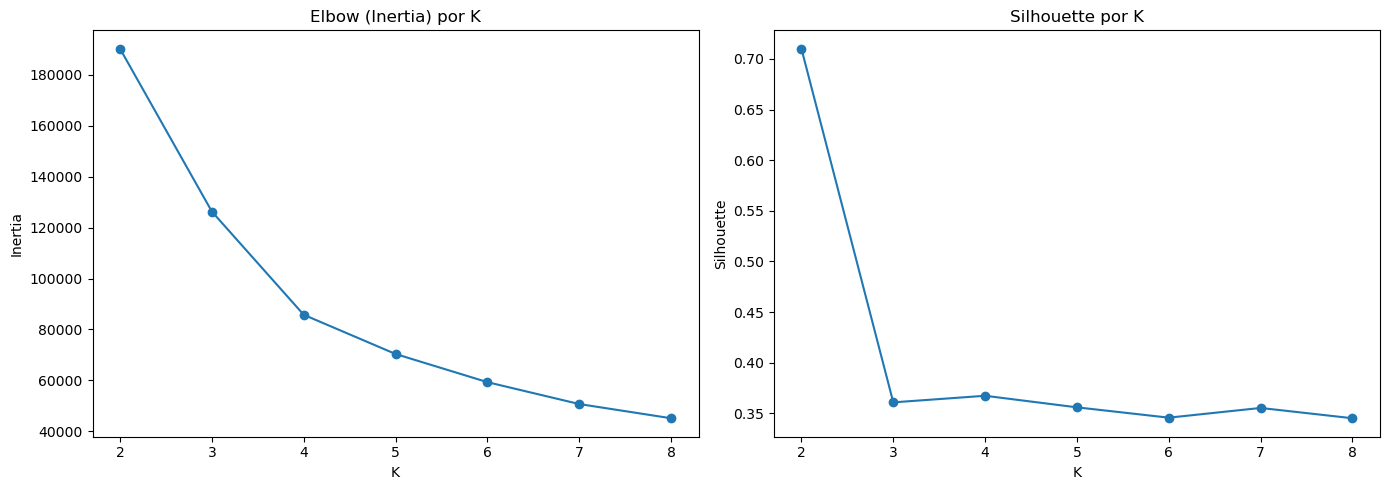

,K,Inertia,Silhouette
0,2,190196.317301,0.709966
2,4,85766.203216,0.367414
1,3,126271.707830,0.360919
3,5,70374.077291,0.355990
5,7,50726.050889,0.355393
4,6,59318.361906,0.345804
6,8,45149.248355,0.345223


In [36]:
# Inercia (elbow) e silhouette para K de 2 a 8
k_results = elbow_silhouette(
    rfm,
    k_range=range(2, 9),
    random_state=CONFIG["clustering"]["random_state"],
)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(k_results["K"], k_results["Inertia"], marker="o")
ax[0].set_title("Elbow (Inertia) por K")
ax[0].set_xlabel("K")
ax[0].set_ylabel("Inertia")

ax[1].plot(k_results["K"], k_results["Silhouette"], marker="o")
ax[1].set_title("Silhouette por K")
ax[1].set_xlabel("K")
ax[1].set_ylabel("Silhouette")
plt.tight_layout()
plt.show()

k_results.sort_values("Silhouette", ascending=False)


## 7) Clusterização final (K-Means)
**K = 4** foi adotado como padrão de negócio: é o ponto de equilíbrio entre qualidade estatística (silhouette) e interpretabilidade — quatro segmentos são facilmente acionáveis por times de CRM e marketing.

In [37]:
# Treina pipeline final e serializa com joblib
# Modelo + metadados salvos em models/rfm_pipeline.pkl e models/model_metadata.json
pipeline = fit_and_save(rfm, CONFIG, output_dir=CONFIG["paths"]["models"])

# Prediz clusters
rfm["Cluster"] = predict_clusters(rfm, pipeline)
rfm["Cluster"].value_counts().sort_index()


2026-05-10 17:31:37 | src.clustering | INFO | KMeans treinado: K=4 | Silhouette=0.3693 | N=93,358


2026-05-10 17:31:37 | src.clustering | INFO | Pipeline salvo em: models\rfm_pipeline.pkl


2026-05-10 17:31:37 | src.clustering | INFO | Metadados salvos em: models\model_metadata.json


Cluster
0    35872
1     2801
2    27051
3    27634
Name: count, dtype: int64

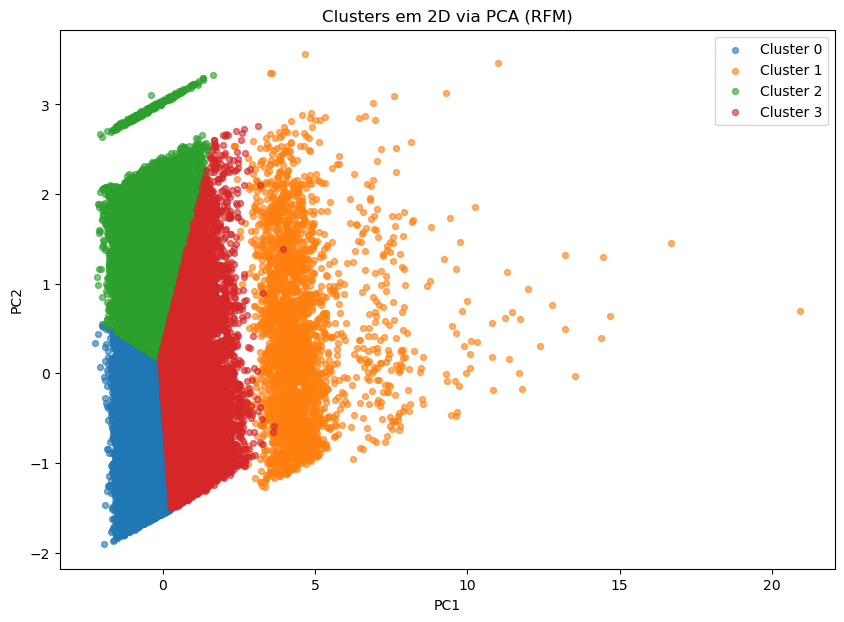

(array([0.38919753, 0.33231107]), np.float64(0.7215085954731599))

In [38]:
# PCA 2D para visualização
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

viz = pd.DataFrame({"PC1": X_pca[:, 0], "PC2": X_pca[:, 1], "Cluster": rfm["Cluster"].astype(int)})

plt.figure(figsize=(10, 7))
for c in sorted(viz["Cluster"].unique()):
    subset = viz[viz["Cluster"] == c]
    plt.scatter(subset["PC1"], subset["PC2"], alpha=0.6, label=f"Cluster {c}", s=18)

plt.title("Clusters em 2D via PCA (RFM)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

pca.explained_variance_ratio_, pca.explained_variance_ratio_.sum()


In [39]:
# Perfil dos clusters (média e mediana) + tamanho
profile = (
    rfm.groupby("Cluster")
    .agg(
        Qtd_Clientes=("customer_unique_id", "count"),
        Recency_mean=("Recency", "mean"),
        Recency_median=("Recency", "median"),
        Frequency_mean=("Frequency", "mean"),
        Frequency_median=("Frequency", "median"),
        Monetary_mean=("Monetary", "mean"),
        Monetary_median=("Monetary", "median"),
        AOV_mean=("Avg_Order_Value", "mean"),
        Review_mean=("Avg_Review", "mean"),
    )
    .reset_index()
)

profile


,Cluster,Qtd_Clientes,Recency_mean,Recency_median,Frequency_mean,Frequency_median,Monetary_mean,Monetary_median,AOV_mean,Review_mean
0,0,35872,151.890388,151.0,1.000000,1.0,69.456238,66.31,69.456238,4.190723
1,1,2801,224.809354,204.0,2.113888,2.0,308.588793,225.55,145.868157,4.203186
2,2,27051,429.604747,422.0,1.000000,1.0,119.105699,97.99,119.105699,4.218214
3,3,27634,178.685786,174.0,1.000000,1.0,320.068651,211.92,320.068651,4.036063


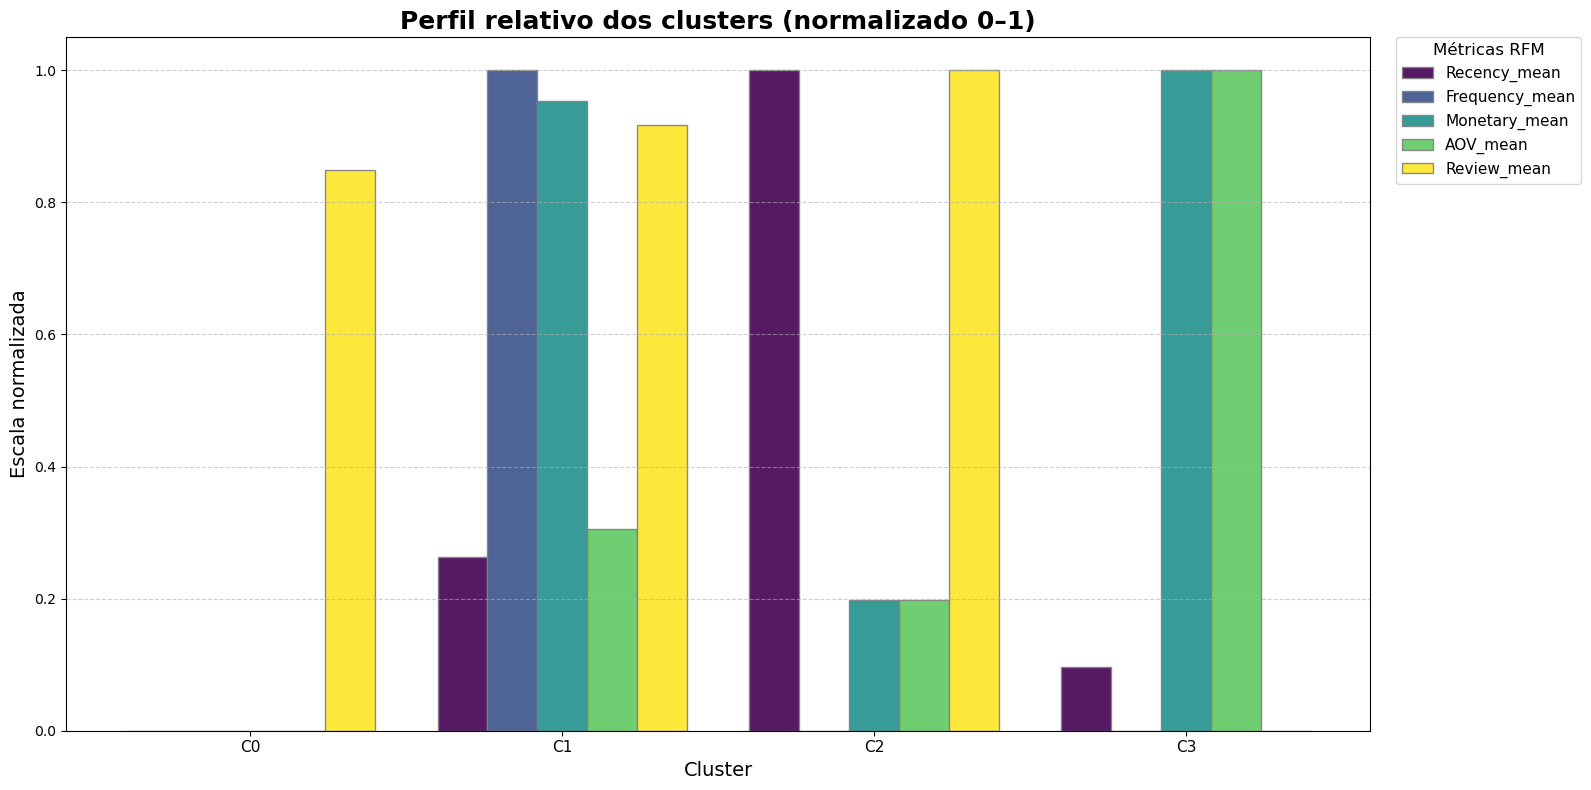

In [41]:
# Visual: barras normalizadas (para comparar perfis)
to_plot = profile.copy()
cols = ["Recency_mean", "Frequency_mean", "Monetary_mean", "AOV_mean", "Review_mean"]

# Normaliza para 0-1 por coluna para facilitar leitura
norm = to_plot[cols].copy()
for col in cols:
    norm[col] = (norm[col] - norm[col].min()) / (norm[col].max() - norm[col].min() + 1e-9)

x = np.arange(len(to_plot["Cluster"]))
w = 0.16  # Largura da barra

plt.figure(figsize=(16, 8))  # Aumenta o tamanho da figura
colors = plt.cm.get_cmap("viridis", len(cols))  # Usa uma paleta de cores moderna

for i, col in enumerate(cols):
    plt.bar(x + i * w, norm[col], width=w, label=col, color=colors(i), edgecolor="grey", alpha=0.9)

# Calcula a posição central para os xticks
xtick_positions = x + (len(cols) - 1) * w / 2
plt.xticks(
    xtick_positions, [f"C{c}" for c in to_plot["Cluster"]], rotation=0, fontsize=11
)  # Centraliza e melhora o texto

plt.title("Perfil relativo dos clusters (normalizado 0–1)", fontsize=18, fontweight="bold")
plt.xlabel("Cluster", fontsize=14)
plt.ylabel("Escala normalizada", fontsize=14)
plt.legend(
    title="Métricas RFM",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0.0,
    fontsize=11,
    title_fontsize="12",
)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


## 8) Naming (tradução para negócio)
Os clusters são nomeados a partir da posição relativa de cada um em Recency, Frequency e Monetary, traduzindo perfis estatísticos em rótulos acionáveis para CRM.

In [42]:
# Heurística simples: ranks por cluster (quanto maior melhor em F e M; quanto menor melhor em R)
tmp = profile[["Cluster", "Recency_mean", "Frequency_mean", "Monetary_mean"]].copy()

tmp["R_rank"] = tmp["Recency_mean"].rank(ascending=True)  # menor recency = melhor
tmp["F_rank"] = tmp["Frequency_mean"].rank(ascending=False)
tmp["M_rank"] = tmp["Monetary_mean"].rank(ascending=False)

tmp["Score"] = tmp["R_rank"] + tmp["F_rank"] + tmp["M_rank"]

tmp.sort_values("Score")


,Cluster,Recency_mean,Frequency_mean,Monetary_mean,R_rank,F_rank,M_rank,Score
1,1,224.809354,2.113888,308.588793,3.0,1.0,2.0,6.0
3,3,178.685786,1.000000,320.068651,2.0,3.0,1.0,6.0
0,0,151.890388,1.000000,69.456238,1.0,3.0,4.0,8.0
2,2,429.604747,1.000000,119.105699,4.0,3.0,3.0,10.0


In [43]:
# Nomeacao derivada do perfil R/F/M de cada cluster (nao do ID do KMeans):
# 1. Em Risco / Hibernando = cluster com maior Recency media
# 2. Campeoes = maior (Frequency x Monetary) entre os restantes
# 3. Big Spenders = maior Monetary entre os 2 restantes
# 4. Novos / Ocasionais = o ultimo cluster restante
# Assim os nomes permanecem coerentes mesmo que os IDs mudem entre execucoes.

rfm = assign_cluster_names(rfm)

print("\n=== Distribuicao final por cluster nomeado ===")
print(rfm["Cluster_Name"].value_counts())

# Inspeciona o perfil + nome atribuido (para validacao visual)
from src.segmentation import build_cluster_profile

profile_named = build_cluster_profile(rfm).merge(
    rfm[["Cluster", "Cluster_Name"]].drop_duplicates(), on="Cluster"
)
profile_named


2026-05-10 17:31:38 | src.segmentation | INFO | Perfil dos clusters → nome de negócio derivado:


2026-05-10 17:31:38 | src.segmentation | INFO |   Cluster 0: R̄=152d | F̄=1.00 | M̄=R$69.46 | n=35,872 → Novos / Ocasionais


2026-05-10 17:31:38 | src.segmentation | INFO |   Cluster 1: R̄=225d | F̄=2.11 | M̄=R$308.59 | n=2,801 → Campeões


2026-05-10 17:31:38 | src.segmentation | INFO |   Cluster 2: R̄=430d | F̄=1.00 | M̄=R$119.11 | n=27,051 → Em Risco / Hibernando


2026-05-10 17:31:38 | src.segmentation | INFO |   Cluster 3: R̄=179d | F̄=1.00 | M̄=R$320.07 | n=27,634 → Big Spenders (Não-Recorrentes)


2026-05-10 17:31:38 | src.segmentation | INFO | Cluster_Name atribuído:
Cluster_Name
Novos / Ocasionais                35872
Big Spenders (Não-Recorrentes)    27634
Em Risco / Hibernando             27051
Campeões                           2801



=== Distribuicao final por cluster nomeado ===
Cluster_Name
Novos / Ocasionais                35872
Big Spenders (Não-Recorrentes)    27634
Em Risco / Hibernando             27051
Campeões                           2801
Name: count, dtype: int64


,Cluster,R_mean,F_mean,M_mean,n_clientes,AOV_mean,Cluster_Name
0,0,151.890388,1.000000,69.456238,35872,69.456238,Novos / Ocasionais
1,1,224.809354,2.113888,308.588793,2801,145.868157,Campeões
2,2,429.604747,1.000000,119.105699,27051,119.105699,Em Risco / Hibernando
3,3,178.685786,1.000000,320.068651,27634,320.068651,Big Spenders (Não-Recorrentes)


## 9) Validação estatística dos insights
Como RFM costuma ser não-normal (caudas longas), usamos duas abordagens:
- **ANOVA** (paramétrico) — útil como referência
- **Kruskal-Wallis** (não-paramétrico) — robusto para assimetria

Em seguida, aplicamos **post-hoc** (Tukey) para identificar quais pares de clusters diferem.

In [44]:
def anova_by_cluster(df, col):
    groups = [df[df["Cluster"] == c][col].dropna() for c in sorted(df["Cluster"].unique())]
    return stats.f_oneway(*groups)


def kruskal_by_cluster(df, col):
    groups = [df[df["Cluster"] == c][col].dropna() for c in sorted(df["Cluster"].unique())]
    return stats.kruskal(*groups)


tests = {}
for col in ["Recency", "Frequency", "Monetary", "Avg_Order_Value", "Avg_Review"]:
    tests[col] = {"ANOVA": anova_by_cluster(rfm, col), "Kruskal": kruskal_by_cluster(rfm, col)}

tests


{'Recency': {'ANOVA': F_onewayResult(statistic=np.float64(51486.15818009213), pvalue=np.float64(0.0)),
  'Kruskal': KruskalResult(statistic=np.float64(54141.741539371105), pvalue=np.float64(0.0))},
 'Frequency': {'ANOVA': F_onewayResult(statistic=np.float64(147608.17357911027), pvalue=np.float64(0.0)),
  'Kruskal': KruskalResult(statistic=np.float64(93350.51459290467), pvalue=np.float64(0.0))},
 'Monetary': {'ANOVA': F_onewayResult(statistic=np.float64(9371.166830796288), pvalue=np.float64(0.0)),
  'Kruskal': KruskalResult(statistic=np.float64(54130.27415044459), pvalue=np.float64(0.0))},
 'Avg_Order_Value': {'ANOVA': F_onewayResult(statistic=np.float64(9443.754920948733), pvalue=np.float64(0.0)),
  'Kruskal': KruskalResult(statistic=np.float64(52363.759171324775), pvalue=np.float64(0.0))},
 'Avg_Review': {'ANOVA': F_onewayResult(statistic=np.float64(111.53690802691716), pvalue=np.float64(4.3219361651325946e-72)),
  'Kruskal': KruskalResult(statistic=np.float64(195.18369469429712), pva

In [45]:
# Post-hoc (Tukey) para identificar quais pares de clusters diferem
if HAS_STATSMODELS:
    for col in ["Monetary", "Frequency", "Recency"]:
        sample = rfm[["Cluster", col]].dropna()
        tuk = pairwise_tukeyhsd(endog=sample[col], groups=sample["Cluster"], alpha=0.05)
        print(f"\nTukey HSD - {col}")
        print(tuk.summary())
else:
    print("statsmodels nao disponivel. Para post-hoc Tukey: pip install statsmodels")



Tukey HSD — Monetary
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower     upper   reject
---------------------------------------------------------
     0      1  239.1326    0.0  229.1325  249.1326   True
     0      2   49.6495    0.0   45.5449    53.754   True
     0      3  250.6124    0.0  246.5326  254.6922   True
     1      2 -189.4831    0.0 -199.6005 -179.3657   True
     1      3   11.4799 0.0185    1.3725   21.5873   True
     2      3   200.963    0.0  196.6033  205.3226   True
---------------------------------------------------------



Tukey HSD — Frequency
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
     0      1   1.1139   0.0  1.1095  1.1183   True
     0      2      0.0   1.0 -0.0018  0.0018  False
     0      3      0.0   1.0 -0.0018  0.0018  False
     1      2  -1.1139   0.0 -1.1183 -1.1094   True
     1      3  -1.1139   0.0 -1.1183 -1.1094   True
     2      3      0.0   1.0 -0.0019  0.0019  False
---------------------------------------------------



Tukey HSD — Recency
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj  lower     upper   reject
------------------------------------------------------
     0      1   72.919   0.0  68.1983   77.6396   True
     0      2 277.7144   0.0 275.7768   279.652   True
     0      3  26.7954   0.0  24.8695   28.7213   True
     1      2 204.7954   0.0 200.0194  209.5714   True
     1      3 -46.1236   0.0 -50.8949  -41.3523   True
     2      3 -250.919   0.0 -252.977 -248.8609   True
------------------------------------------------------


## 10) Enriquecimento — Reviews e Pagamentos
Conectamos o comportamento de compra (RFM) com variáveis de experiência:
- **Satisfação** (review_score)
- **Método de pagamento** (distribuição por cluster)

O objetivo é explicar os clusters além do RFM e apoiar ações de CRM segmentadas.

In [46]:
# Método de pagamento predominante por pedido (maior payment_value)
pay_type = payments.groupby(["order_id", "payment_type"], as_index=False).agg(
    payment_value=("payment_value", "sum")
)

# Pega o método com maior valor por pedido
pay_main = pay_type.sort_values(
    ["order_id", "payment_value"], ascending=[True, False]
).drop_duplicates("order_id")
pay_main = pay_main[["order_id", "payment_type"]]

orders_enriched = orders_base.merge(pay_main, on="order_id", how="left")

# Junta cluster por customer_unique_id
orders_enriched = orders_enriched.merge(
    rfm[["customer_unique_id", "Cluster", "Cluster_Name"]], on="customer_unique_id", how="left"
)

orders_enriched[["order_id", "payment_type", "review_score", "Cluster_Name"]].head()


,order_id,payment_type,review_score,Cluster_Name
0,e481f51cbdc54678b7cc49136f2d6af7,voucher,4.0,Campeões
1,53cdb2fc8bc7dce0b6741e2150273451,boleto,4.0,Big Spenders (Não-Recorrentes)
2,47770eb9100c2d0c44946d9cf07ec65d,credit_card,5.0,Big Spenders (Não-Recorrentes)
3,949d5b44dbf5de918fe9c16f97b45f8a,credit_card,5.0,Novos / Ocasionais
4,ad21c59c0840e6cb83a9ceb5573f8159,credit_card,5.0,Novos / Ocasionais


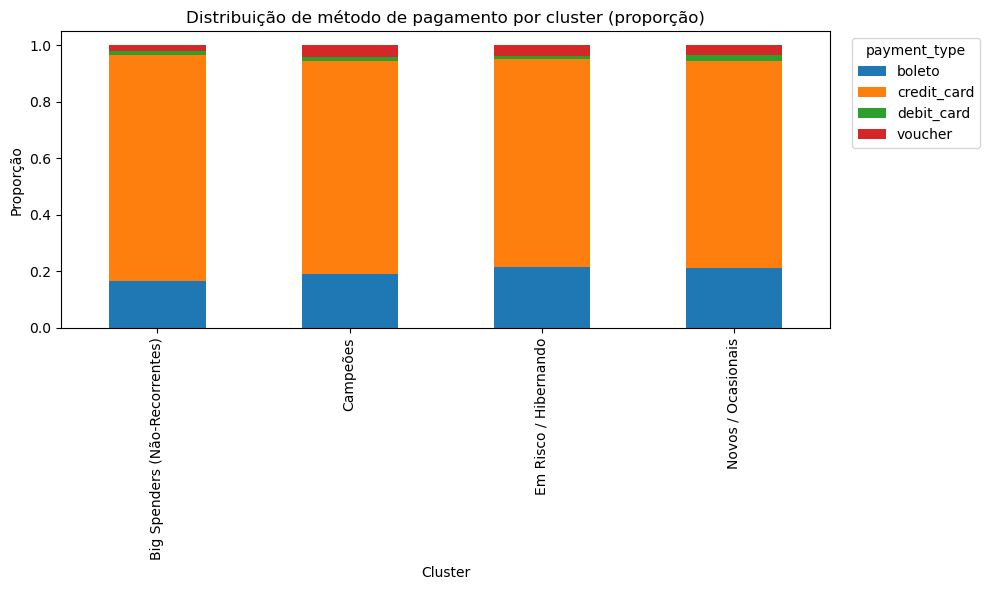

In [47]:
# Distribuição de payment_type por cluster (proporção)
dist = (
    orders_enriched.dropna(subset=["payment_type"])
    .groupby(["Cluster_Name", "payment_type"])
    .size()
    .reset_index(name="n")
)

dist["pct"] = dist.groupby("Cluster_Name")["n"].transform(lambda x: x / x.sum())

# Plot top methods (stacked bars)
pivot = dist.pivot_table(
    index="Cluster_Name", columns="payment_type", values="pct", fill_value=0
).sort_index()
pivot.plot(kind="bar", stacked=True)
plt.title("Distribuição de método de pagamento por cluster (proporção)")
plt.xlabel("Cluster")
plt.ylabel("Proporção")
plt.legend(title="payment_type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [48]:
# Teste qui-quadrado: payment_type independe do cluster?
# (amostra: pedidos com payment_type e cluster)
ct = pd.crosstab(orders_enriched["Cluster_Name"], orders_enriched["payment_type"])
chi2, p, dof, expected = stats.chi2_contingency(ct)
chi2, p, dof


(np.float64(669.9517949653616), np.float64(1.987317293395499e-138), 9)

O teste qui-quadrado rejeita a hipótese de independência (p-value ≪ 0.05): **o método de pagamento varia por cluster**.
Essa diferença pode orientar a estratégia comercial — por exemplo, condições de parcelamento específicas para segmentos de maior valor.

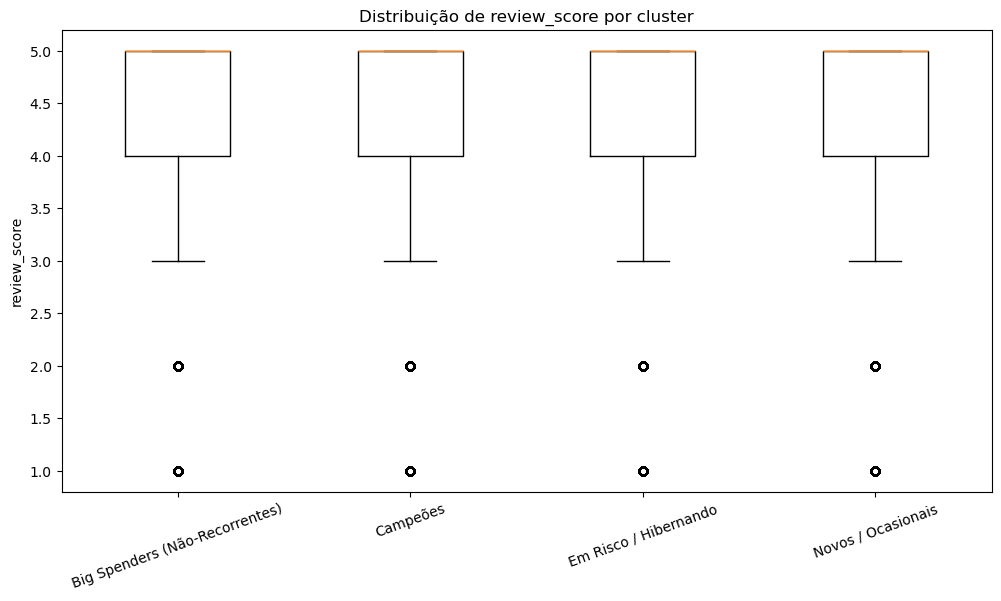

KruskalResult(statistic=np.float64(195.99082929243758), pvalue=np.float64(3.100196924754031e-42))

In [49]:
# Reviews por cluster — boxplot para ver diferenças e dispersão
data = orders_enriched.dropna(subset=["review_score"]).copy()

# Boxplot por cluster_name
labels = sorted(data["Cluster_Name"].unique())
vals = [data[data["Cluster_Name"] == c]["review_score"] for c in labels]

plt.figure(figsize=(12, 6))
plt.boxplot(vals, labels=labels, vert=True)
plt.title("Distribuição de review_score por cluster")
plt.ylabel("review_score")
plt.xticks(rotation=20)
plt.show()

# Teste não paramétrico (Kruskal) para review_score por cluster_name
groups = [data[data["Cluster_Name"] == c]["review_score"] for c in labels]
stats.kruskal(*groups)


## 11) Exportação (Power BI / CRM) — Star Schema

Os 4 arquivos abaixo formam um modelo dimensional pronto para Power BI:

- **`fato_rfm_clientes.csv`** — 1 linha por cliente (RFM + cluster + segmentos + CLV)
- **`fato_pedidos.csv`** — 1 linha por pedido (com cluster e método de pagamento)
- **`dim_segmentos.csv`** — dimensão com nome, cor, descrição e ação CRM por cluster
- **`dim_calendario.csv`** — calendário completo (Ano, Mês, Trimestre, etc.) para inteligência temporal

Esses datamarts permitem dashboards do tipo:
- visão por segmento (tamanho, gasto, recência, ticket médio)
- evolução temporal de receita por cluster
- satisfação (review) e método de pagamento por segmento
- análise de concentração Pareto e KPIs de saúde da base

In [50]:
# Customer Lifetime Value (CLV simples)
# Projecao de 12 meses: AOV x frequencia mensal estimada x 12
rfm = calculate_clv_simple(rfm, horizon_months=12)

print(f"CLV medio projetado (12 meses): R${rfm['CLV_12m'].mean():.2f}")
print(f"CLV mediano: R${rfm['CLV_12m'].median():.2f}")
rfm[["customer_unique_id", "Cluster_Name", "Monetary", "CLV_12m"]].head(10)


2026-05-10 17:31:41 | src.segmentation | INFO | CLV simples calculado. Média CLV_12m: R$82.60


CLV medio projetado (12 meses): R$82.60
CLV mediano: R$53.89


,customer_unique_id,Cluster_Name,Monetary,CLV_12m
0,0a0a92112bd4c708ca5fde585afaa872,Big Spenders (Não-Recorrentes),13664.08,6832.04
1,da122df9eeddfedc1dc1f5349a1a690c,Campeões,7571.63,3785.81
2,763c8b1c9c68a0229c42c9fc6f662b93,Big Spenders (Não-Recorrentes),7274.88,3637.44
3,dc4802a71eae9be1dd28f5d788ceb526,Big Spenders (Não-Recorrentes),6929.31,3464.66
4,459bef486812aa25204be022145caa62,Big Spenders (Não-Recorrentes),6922.21,3461.10
5,ff4159b92c40ebe40454e3e6a7c35ed6,Big Spenders (Não-Recorrentes),6726.66,3363.33
6,4007669dec559734d6f53e029e360987,Big Spenders (Não-Recorrentes),6081.54,3040.77
7,eebb5dda148d3893cdaf5b5ca3040ccb,Big Spenders (Não-Recorrentes),4764.34,2382.17
8,48e1ac109decbb87765a3eade6854098,Big Spenders (Não-Recorrentes),4681.78,2340.89
9,c8460e4251689ba205045f3ea17884a1,Campeões,4655.91,2327.96


In [51]:
# Exportacao tipada para Power BI
# Usa src/export.py com tipagem explicita e encoding utf-8-sig (BOM)
from pathlib import Path

output_dir = Path(CONFIG["paths"]["powerbi_output"])
output_dir.mkdir(parents=True, exist_ok=True)

# fato_rfm_clientes.csv - tabela fato principal
export_rfm_to_powerbi(rfm, output_dir / "fato_rfm_clientes.csv")

# fato_pedidos.csv
pay_main = (
    payments.groupby(["order_id", "payment_type"], as_index=False)
    .agg(payment_value=("payment_value", "sum"))
    .sort_values(["order_id", "payment_value"], ascending=[True, False])
    .drop_duplicates("order_id")[["order_id", "payment_type"]]
)
orders_enriched = orders_base.merge(pay_main, on="order_id", how="left")
orders_enriched = orders_enriched.merge(
    rfm[["customer_unique_id", "Cluster", "Cluster_Name"]],
    on="customer_unique_id",
    how="left",
)
export_orders_to_powerbi(orders_enriched, output_dir / "fato_pedidos.csv")

# dim_segmentos.csv
dim_seg = build_dim_segmentos()
dim_seg.to_csv(output_dir / "dim_segmentos.csv", index=False, encoding=CONFIG["export"]["encoding"])
logger.info("Exportado: dim_segmentos.csv (%d linhas)", len(dim_seg))

# dim_calendario.csv
dim_cal = build_dim_calendario(start="2016-01-01", end="2018-12-31")
dim_cal.to_csv(
    output_dir / "dim_calendario.csv", index=False, encoding=CONFIG["export"]["encoding"]
)
logger.info("Exportado: dim_calendario.csv (%d linhas)", len(dim_cal))

print("\n=== Exportacao concluida! ===")
print(f"Arquivos em: {output_dir.resolve()}")


2026-05-10 17:31:42 | src.export | INFO | Exportado: data\powerbi\fato_rfm_clientes.csv (93,358 linhas × 25 colunas)


2026-05-10 17:31:44 | src.export | INFO | Exportado: data\powerbi\fato_pedidos.csv (96,478 linhas)


2026-05-10 17:31:44 | __main__ | INFO | Exportado: dim_segmentos.csv (4 linhas)


2026-05-10 17:31:44 | src.export | INFO | dim_calendario criada: 1,096 datas (2016-01-01 → 2018-12-31)


2026-05-10 17:31:44 | __main__ | INFO | Exportado: dim_calendario.csv (1096 linhas)



=== Exportacao concluida! ===
Arquivos em: C:\Users\Luk\Desktop\RFM-Projeto\data\powerbi


## Conclusões

A análise mostrou que a base de clientes da Olist possui baixa recorrência, o que limita o poder explicativo do RFM clássico quando utilizado isoladamente, especialmente na dimensão de frequência. Para contornar essa limitação, o projeto combinou três camadas complementares: RFM, segmentação estratégica por valor e recência, e clusterização comportamental.

Com isso, foi possível identificar grupos mais acionáveis para negócio, como clientes de maior valor com potencial de fidelização, perfis de alto gasto sem recorrência, clientes recentes de baixo valor e uma base claramente hibernando, que pode ser trabalhada com campanhas de reativação.

Além disso, a inclusão de variáveis de experiência, como review score e método de pagamento, ampliou a capacidade analítica do projeto, aproximando a segmentação de aplicações reais em CRM, retenção, operação e priorização comercial.

Como entrega final, o projeto gera datamarts prontos para Power BI, permitindo transformar a análise em dashboards executivos e acompanhamento contínuo dos segmentos.

## Recomendações de negócio

### Ações priorizadas por cluster

#### 1. Campeões (Prioridade ALTA — proteger receita)
- **Programa VIP exclusivo**: acesso antecipado a coleções, frete grátis ilimitado, atendimento dedicado.
- **Programa de embaixadores**: convidar para gerar conteúdo / indicar amigos com cashback.
- **Comunicação 1-to-1**: e-mails personalizados, ofertas baseadas em histórico.
- **KPI de monitoramento**: % de Campeões retidos a cada trimestre.

#### 2. Big Spenders Não-Recorrentes (Prioridade ALTA — converter para recorrência)
- **Pós-venda ativo**: e-mail 7/15/30 dias após a compra com produtos complementares (cross-sell).
- **Cupom de retorno**: desconto progressivo na 2ª compra (ex: 15% na 2ª, 10% na 3ª).
- **Pesquisa de satisfação**: entender por que não retornam — preço, sortimento, experiência?
- **KPI de monitoramento**: taxa de conversão da 1ª para a 2ª compra.

#### 3. Novos / Ocasionais (Prioridade MÉDIA — engajar a maioria)
- **Onboarding estruturado**: série de e-mails educativos sobre marketplace e categorias relevantes.
- **Cupom "volte logo"**: incentivo de baixo custo (ex: R$ 20 OFF) com validade curta.
- **Cross-sell baseado em categoria**: recomendações via filtro colaborativo simples.
- **KPI de monitoramento**: % de Novos que viram Campeões em 6 meses.

#### 4. Em Risco / Hibernando (Prioridade ALTA — win-back urgente)
- **Campanha de reativação**: e-mail/SMS com oferta agressiva (ex: 30% OFF + frete grátis).
- **Pesquisa de churn**: entender o motivo da inatividade.
- **Re-engajamento gradual**: se ignorarem 2 campanhas, reduzir a frequência para não queimar a lista.
- **KPI de monitoramento**: taxa de win-back por janela de recência.

### Recomendações transversais

- **Investir em retenção mais que em aquisição.** O custo de reativar um cliente é tipicamente menor do que o de adquirir um novo.
- **Construir programa de fidelidade.** A baixa frequência é o principal gargalo da base — qualquer mecânica que aumente F tem alavancagem direta em LTV.
- **Monitorar a concentração mensalmente.** Se o Gini aumentar, é sinal de dependência excessiva de poucos clientes (risco de receita).

### Impacto financeiro estimado

Considerando que os clusters de **Campeões + Big Spenders** representam a maior parcela da receita (concentração de Pareto observada), uma melhoria de **5 pontos percentuais na retenção** desses segmentos pode representar incremento relevante de GMV anual — vale priorizar ações nesses dois grupos.

## Próximos passos

### Curto prazo (1-2 semanas)

1. **Construir o dashboard Power BI** usando os 4 datamarts exportados:
 - `fato_rfm_clientes.csv` — visão agregada por cliente
 - `fato_pedidos.csv` — visão transacional por pedido
 - `dim_segmentos.csv` — apoio para classificação e legenda
 - `dim_calendario.csv` — inteligência temporal

2. **Modelar o Star Schema** com relacionamentos:
 - `dim_calendario[Data]` 1:N `fato_pedidos[order_purchase_date]`
 - `dim_segmentos[Cluster_Name]` 1:N `fato_rfm_clientes[Cluster_Name]`

3. **Criar medidas DAX essenciais**:
 - Total Clientes
 - Receita Total
 - Ticket Médio
 - Recência Média
 - % Clientes Recorrentes
 - CLV Médio por Cluster

### Médio prazo (3-4 semanas)

4. **Aprofundar o modelo de CLV**:
 - substituir o CLV simples por abordagem probabilística (BG/NBD + Gamma-Gamma via biblioteca `lifetimes`)
 - estimar churn e valor esperado por cliente

5. **Validar ações em testes segmentados**:
 - selecionar amostras por cluster
 - aplicar ações de CRM específicas
 - medir taxa de retorno e uplift vs grupo de controle

6. **Automatizar o pipeline**:
 - agendar a atualização periódica dos datamarts (ex: Airflow / cron rodando `pipeline/run_pipeline.py`)
 - versionar os arquivos gerados para histórico analítico

### Longo prazo (2-3 meses)

7. **Integrar a segmentação com ferramentas de CRM** (HubSpot, RD Station, Mailchimp), com disparo automático de campanhas baseado em mudança de cluster.

8. **Evoluir para modelos de churn e LTV** (modelos supervisionados de propensão de compra e probabilidade de churn em 30/60/90 dias).

9. **Criar monitoramento contínuo da migração entre clusters** — acompanhar mensalmente quantos clientes saem de "Em Risco" para "Campeões" (e vice-versa) como KPI de saúde da base.